# DAS Cable Anomaly Detection

End-to-end **unsupervised anomaly detection** for submarine power-cable
health monitoring using Distributed Acoustic Sensing (DAS), following the
**CRISP-DM** methodology. Combines DSP feature engineering with an
Isolation Forest anomaly detector -- from raw HDF5 strain-rate recordings to
a deployed REST API.

**Dataset:** Valencia-IslaLink DAS (PubDAS) -- Valencia-to-Mallorca telecom
fiber, Sept 2020, Febus A1-R interrogator, 250 Hz, 16.8 m channel spacing
**Signal:** Optical strain rate along the fiber (per-channel, per-sample)
**Task:** fully unsupervised anomaly detection -- **no ground truth anywhere
in this dataset** (see Section 9's limitations)
**Model:** Isolation Forest (One-Class SVM tried and dropped, see Section 4)


In [66]:
# =========================================================
# 0. Imports & Configuration
# =========================================================

# --- 0a. Imports ---

# --- Standard library ---
import os
import sys
import glob
import importlib.util
import shutil
import zipfile
import re
import warnings
import time
import hashlib
import pickle
from datetime import datetime, timedelta
from pathlib import Path

os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"   # suppress MLflow progress bars

# --- Third-party core ---
import numpy as np
import pandas as pd
from tqdm import tqdm

# --- Visualisation ---
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy.signal import stft, welch  # detrend/butter/filtfilt now live in utils/data_preprocess.py
from scipy.stats import kurtosis, spearmanr
from scipy import fft as sp_fft  # 2c's f-k spectrum plot -- scipy.fft (not numpy.fft) preserves
                                 # single precision, same reason utils/data_preprocess.fk_filter() uses it (CLAUDE.md SS9)

try:
    import pywt
    HAS_PYWT = True
except ImportError:
    HAS_PYWT = False
    print("pywt not found -- pip install PyWavelets (WPD features will be skipped)")

# Import torch before scikit-learn (Windows-only DLL load-order quirk):
# scikit-learn's bundled vcomp140.dll loads into the process first otherwise,
# which breaks PyTorch's own vcomp140 dependency (shap imports torch internally
# for its image masker) with "OSError: [WinError 1114] DLL load failed".
import torch

# --- scikit-learn ---
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.preprocessing import StandardScaler

# --- Other ML ---
import shap
import mlflow
import yaml  # bundled with mlflow — used by the run-retention helper below


warnings.filterwarnings("ignore")

# --- Project modules (all live in utils/) ---
_BASE_DIR = (
    Path(__file__).parent
    if "__file__" in dir()
    else Path(globals()["__vsc_ipynb_file__"]).parent
    if "__vsc_ipynb_file__" in globals()
    else Path().resolve()
)
# Auto-correct: if CWD is the workspace root rather than the project folder,
# step into distributed-acoustic-sensing/ and change the working directory.
# os.chdir is the most reliable fix: even MLflow fallback paths use CWD.
if not (_BASE_DIR / "utils" / "data_loader.py").exists():
    _BASE_DIR = _BASE_DIR / "distributed-acoustic-sensing"
assert (_BASE_DIR / "utils" / "data_loader.py").exists(), (
    "_BASE_DIR wrong: " + str(_BASE_DIR)
)
os.chdir(_BASE_DIR)  # pin CWD to project root — prevents mlruns from being created in parent
_UTILS = _BASE_DIR / "utils"
mlflow.set_tracking_uri(f"file:///{(_BASE_DIR / 'mlruns').as_posix()}")

def _load_module(name: str, path: Path, inject: bool = True):
    """Load a local .py module and optionally inject its public names here."""
    spec = importlib.util.spec_from_file_location(name, path)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    if inject:
        _public = {k: v for k, v in vars(mod).items() if not k.startswith('_')}
        globals().update(_public)
    return mod

_load_module("download_dataset",  _UTILS / "download_dataset.py")
_load_module("data_loader",       _UTILS / "data_loader.py")
_load_module("data_preprocess",   _UTILS / "data_preprocess.py")
_load_module("dsp_features",      _UTILS / "dsp_features.py")
_load_module("anomaly_models",     _UTILS / "anomaly_models.py")
_load_module("plot_style",        _UTILS / "plot_style.py")

apply_style()  # whitegrid theme, FigSize.DEFAULT, blues(6) colour cycle — see utils/plot_style.py

# plot_style.py's blue/red/diverging palette + 4 FigSize presets are used
# directly by name throughout the notebook (BLUE_2, RED_2, CMAP_DIVERGING, ...)
# -- no notebook-level colour aliasing needed (CLAUDE.md SS5's role mapping:
# background/normal -> blue, flagged/anomalous -> red, continuous score ->
# diverging/sequential).

print("utils/ loaded: download_dataset | data_loader | data_preprocess | dsp_features | anomaly_models | plot_style")

utils/ loaded: download_dataset | data_loader | data_preprocess | dsp_features | anomaly_models | plot_style


In [67]:
# --- 0b. Constants (all tuneable values live here) ---
RANDOM_STATE = 42      # global seed

# Dataset selection - Valencia-IslaLink DAS (PubDAS), downloaded via Globus.
# Each 10-min file is ~1.78 GB (~10.7 GB/hour) - MAX_HOURS bounds disk usage,
# don't raise it without checking available disk space first.
MAX_HOURS = 4

# f-k apparent-velocity highpass (utils/data_preprocess.fk_filter(), called
# from preprocess_channels() -- CLAUDE.md SS9). Lower bound only (highpass,
# not a band -- see fk_filter()'s docstring for why): an unverified starting
# guess at a water-borne acoustic speed, ported from
# old/DAS_Signal_Processing.ipynb's c_ac, not fit to anything in this dataset.
FK_C_LOW = 1400.0

# Channel subsampling -- shared by 2k's waterfall demo AND 3a-ii's batch
# extraction (moved here from 3a-i so 2k, which runs first, can also use it).
# 1 = every channel, 2 = every other (skip 1), 3 = skip 2, ... ~392 of ~1959
# deep-water channels at stride 5 (~84 m effective spacing). Originally
# batch-extraction-only (compute: channels x windows x events); now also
# needed by 2k to keep fk_filter()'s 2D FFT array small enough to fit in
# memory for a full 10-minute file (CLAUDE.md SS9) -- a full-density
# (~1959-channel) call allocates a (1959, ~150000) array per intermediate,
# which was verified directly to raise a MemoryError computing fk_filter()'s
# 2D FFT on this machine.
CHANNEL_STRIDE = 5

# --- EDA tunables (moved here -- used across multiple Section 2 cells, not
# just where each was originally defined: EDA_WINDOW_SEC by 2c/2e/2h/2j/2k,
# EDA_BANDPASS by 2g/2h/2k/2l/3a-ii/7b) ---
EDA_WINDOW_SEC = 60  # seconds shown in every waterfall plot in Section 2

EDA_BANDPASS = (2, 124)  # Hz -- the spectrum in 2e shows where this hour's energy
                         # actually concentrates; also matches this project's own
                         # old/README.md classification table (shipping/vessel noise:
                         # tonal lines 5-50 Hz). Upper bound capped at 124 Hz, just under
                         # this data's Nyquist (fs=250 Hz -> 125 Hz) -- the original 148 Hz
                         # figure was the other PubDAS sub-dataset's (Zhoushan, sampled
                         # faster) and isn't reachable here. NOT the Matlab example's
                         # 0.5-10 Hz, which was tuned to suppress 50 Hz mains hum for a
                         # clean plot, not to isolate vessel signals.

# --- Feature-extraction tunables (moved here -- used by 3a-ii's batch loop,
# 6a-i/ii, and Section 7's screening, not just where each was originally
# defined in 3a-i) ---
# WINDOW_SEC/HOP_SEC: 10s/5s, not the archived notebook's original 60s/30s --
# CLAUDE.md SS9 flagged 60s as possibly too long to see a real transient (each
# point would already average a full minute, long enough to dilute a
# shorter-duration vessel transit into the background) -- 10s/5s stays short
# enough to keep transients visible while still giving a stable per-window
# RMS/PSD estimate.
WINDOW_SEC = 10   # s
HOP_SEC = WINDOW_SEC * 0.5     # s

WPD_WAVELET = 'db4'
WPD_LEVEL = 3
USE_WPD = HAS_PYWT

# PSD_BANDS: non-uniform, concentrated where vessels actually show up -- the
# AIS-correlated study on this dataset found real ship peaks at ~3 Hz and
# ~15 Hz, and this project's own old/README.md classifies shipping noise as
# 5-50 Hz tonal lines. Equal-width bands across the full EDA_BANDPASS range
# would average a thin tonal peak into a broad bin; finer low-frequency bins
# keep it visible. NOT tied to WPD's band count -- WPD can only ever produce
# equal-width 2**WPD_LEVEL bands, which can't match this non-uniform split.
PSD_BANDS = [
    (EDA_BANDPASS[0], 8),    # low vessel range (AIS paper: ~3 Hz peak)
    (8, 20),                 # vessel range (AIS paper: ~15 Hz peak)
    (20, 35),                # upper vessel range (old README: shipping 5-50 Hz)
    (35, 50),                # upper vessel range boundary
    (50, 90),                # mid -- spans the persistent 48/63 Hz interference (CLAUDE.md SS9)
    (90, EDA_BANDPASS[1]),   # high frequency, near the anti-aliasing rolloff
]

# --- Model hyperparameters (moved here -- used by Section 4's registration
# print, 5a's final fit, and 6b's MLflow logging, not just Section 4) ---
IF_N_ESTIMATORS  = 100
# 'auto' (sklearn's own convention), not a guessed rate -- verified directly
# that IsolationForest's contamination-derived offset_ only shifts
# decision_function() by a constant, which cancels out in every rank-based
# comparison this notebook actually uses (Spearman correlation) -- so
# there's nothing to gain by guessing a specific rate here.
IF_CONTAMINATION = 'auto'

# Explainability
SHAP_SAMPLE_SIZE = 200

# --- MLflow ---
RUN_MLFLOW         = True                        # set False to skip all MLflow logging
MLFLOW_EXPERIMENT  = "das-anomaly-detection"     # experiment name in the tracking UI
MLFLOW_KEEP_N_RUNS = 10                           # retention: prune older runs after each logging step

PLOTS_DIR = _BASE_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

_data_dir      = _BASE_DIR / "pubDAS_data" / "Data"
_hours_on_disk = len(discover_events(_data_dir)) if _data_dir.exists() else 0

print(f"Pipeline initialised   {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Base directory         {_BASE_DIR}")
print(f"Plots directory        {PLOTS_DIR}")
print(f"MAX_HOURS              {MAX_HOURS} hour(s) requested  (~{MAX_HOURS * FILES_PER_HOUR * BYTES_PER_FILE / 1e9:.1f} GB)")
print(f"Hours on disk          {_hours_on_disk} complete hour-folder(s) in {_data_dir}")
print(f"RUN_MLFLOW             {RUN_MLFLOW}")


Pipeline initialised   2026-07-02 17:40:00
Base directory         c:\8. DSPandML\distributed-acoustic-sensing
Plots directory        c:\8. DSPandML\distributed-acoustic-sensing\plots
MAX_HOURS              4 hour(s) requested  (~42.9 GB)
Hours on disk          4 complete hour-folder(s) in c:\8. DSPandML\distributed-acoustic-sensing\pubDAS_data\Data
RUN_MLFLOW             True


In [68]:
# --- 0c. Pre-flight DSP Sanity Check ---
# Runs both modules' self-checks on synthetic data before any real data
# loading, so a broken preprocessing or feature-extraction pipeline fails in
# seconds, not after a long download/extraction (CLAUDE.md SS10.3).
preprocess_self_check()
self_check()
print("Pre-flight check OK: data_preprocess.preprocess_self_check() + dsp_features.self_check() passed")


Pre-flight check OK: data_preprocess.preprocess_self_check() + dsp_features.self_check() passed


In [69]:
# --- 0d. Waterfall plot helper ---
def plot_waterfall(signal, time_s, distance_km, title,
                    cbar_label='Strain rate / baseline RMS (dimensionless)',
                    clim_percentile=99.9,
                    scale='db',
                    db_range=30.0,
                    db_ref_percentile=99.9):
    """Render one DAS strain-rate waterfall (time x distance heatmap).

    Shared by every waterfall plot in this notebook (2c, 2k, 2l, 7) so the
    imshow/colorbar/label boilerplate lives in exactly one place instead of
    being copy-pasted at each call site. Only draws the base heatmap --
    callers add overlays (e.g. Section 7's flagged-window rectangles) on the
    returned axes, then handle their own plt.tight_layout()/savefig()/
    show()/close(), since those differ per call site (interactive display
    vs. batch-saved-and-closed).

    Args:
        signal: (n_samples, n_channels) array to display, time along axis 0.
        time_s: Time axis (seconds) matching signal's rows.
        distance_km: Distance axis (km) matching signal's columns.
        title: Axes title.
        cbar_label: Colorbar label -- differs between raw strain rate (2c)
            and baseline-normalized signal (2k/2l/7, the default). For
            scale='db' this is auto-suffixed with the dB reference used.
        clim_percentile: Percentile of |signal| used for the symmetric
            colour limit when scale='linear' (99th by default, matches the
            existing convention). Unused (but still accepted) when
            scale='db'.
        scale: 'linear' (default, unchanged behavior -- signed, symmetric
            colour limit, CMAP_DIVERGING) or 'db' (a one-sided, logarithmic
            power-ratio rendering, useful for revealing weak coherent
            structure a linear percentile scale can wash out or saturate --
            CLAUDE.md SS9). scale='db' is NOT signed/zero-centered, so it
            uses CMAP_BLUE (a plain sequential map, CLAUDE.md SS5), not
            CMAP_DIVERGING -- don't "fix" this later by symmetrizing back to
            vmin=-vmax, that would defeat the point of a dB-re-max scale.
        db_range: Dynamic range in dB shown below the 0 dB reference when
            scale='db' (ignored for scale='linear').
        db_ref_percentile: Percentile of signal POWER (not amplitude) used
            as the 0 dB reference when scale='db' -- near-max, not the
            literal max, so one hot pixel/outlier doesn't set the reference
            (same philosophy as clim_percentile for the linear path, applied
            to power instead of amplitude). Ignored for scale='linear'.

    Returns:
        (fig, ax): the created figure and axes, so callers can add overlays
        before saving/showing.

    Raises:
        ValueError: If scale is not 'linear' or 'db'.
    """
    fig, ax = plt.subplots(figsize=FigSize.WIDE)
    extent = [time_s[0], time_s[-1], distance_km[0], distance_km[-1]]
    if scale == 'linear':
        # High percentile (99th) + interpolation='nearest' -- a high percentile
        # without 'nearest' washes this out (default averaging smooths the
        # actually-rendered pixel values to a smaller range than this clim is
        # computed from, verified directly); with 'nearest', the displayed
        # pixels really are the raw samples, so a high percentile keeps most of
        # the data's dynamic range visible instead of saturating it to the
        # colormap extremes.
        clim = np.nanpercentile(np.abs(signal), clim_percentile)
        im = ax.imshow(signal.T, aspect='auto', origin='lower', extent=extent,
                        cmap=CMAP_DIVERGING, vmin=-clim, vmax=clim, interpolation='nearest')
    elif scale == 'db':
        # Power (amplitude squared), not amplitude, matches the paper's own
        # dB convention. Reference is a near-max percentile of POWER (not a
        # literal max) for the same reason clim_percentile isn't the 100th
        # percentile on the linear path -- one outlier sample shouldn't set
        # the whole colour scale's 0 dB point.
        power = signal ** 2
        ref = np.nanpercentile(power, db_ref_percentile)
        db = 10 * np.log10(np.maximum(power, ref * 1e-6) / ref)
        im = ax.imshow(db.T, aspect='auto', origin='lower', extent=extent,
                        cmap=CMAP_BLUE, vmin=-db_range, vmax=0, interpolation='nearest')
        cbar_label = f'{cbar_label} (dB re {db_ref_percentile:g}th pct)'
    else:
        raise ValueError(f"scale must be 'linear' or 'db', got {scale!r}")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(cbar_label, fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    ax.set_xlabel('Time (s)', fontsize=8)
    ax.set_ylabel('Distance (km)', fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.tick_params(labelsize=7)
    ax.grid(False)  # the ambient seaborn whitegrid theme (apply_style(), Section 0)
                    # obscures fine waterfall structure -- off for every caller of
                    # this shared function (2c/2k/2l/7), not just one call site.
    return fig, ax


## 1. Data Acquisition

`ensure_data` checks whether the required `.mat` files are already present and
downloads only the bearings listed in `BEARING_SET` (default: `MINIMAL_SET`) if missing.
The returned path is the root directory containing one sub-folder per bearing code.

Paderborn dataset structure: 32 bearings (6 healthy, 12 artificially damaged, 14 real damage),
each recorded under 4 operating conditions (speed / torque / radial force combinations).


In [70]:
# =========================================================
# 1. Data Acquisition
# =========================================================

data_dir = ensure_data(max_hours=MAX_HOURS)
print("Data directory:", data_dir)

event_ids = discover_events(data_dir)
if not event_ids:
    raise FileNotFoundError(
        f"No complete events (hour-folders) found under {data_dir}. "
        "Re-run ensure_data() or check Globus Connect Personal is online."
    )

EXAMPLE_EVENT = event_ids[0]
EXAMPLE_FILES = list_event_files(data_dir, EXAMPLE_EVENT)
print(f"Example event   : {EXAMPLE_EVENT}")
print(f"Files in event  : {len(EXAMPLE_FILES)}")
print(f"Events available: {len(event_ids)}")


Valencia-IslaLink DAS Dataset (PubDAS) - Globus Downloader
Hours requested : 4 (~42.9 GB)
  SR_Valencia_2020-09-01_13-21-28_UTC: already complete (6 files)
  SR_Valencia_2020-09-01_14-21-29_UTC: already complete (6 files)
  SR_Valencia_2020-09-01_15-21-30_UTC: already complete (6 files)
  SR_Valencia_2020-09-01_16-21-31_UTC: already complete (6 files)

Dataset ready: all 4 hour(s) found in c:\8. DSPandML\distributed-acoustic-sensing\pubDAS_data\Data
Data directory: c:\8. DSPandML\distributed-acoustic-sensing\pubDAS_data\Data
Example event   : SR_Valencia_2020-09-01_13-21-28_UTC
Files in event  : 6
Events available: 4


## 2. Exploratory Data Analysis

This project monitors only the **undersea** portion of the cable (consistent with
the "submarine power-cable health monitoring" business case in CLAUDE.md) -- the
onland portion is out of scope everywhere in this notebook, not just in the geometry
plot below. `UNDERSEA_FIRST_CHANNEL` (set in 2a) is the 0-indexed channel where the
undersea section begins; every later cell loads/slices from there on, and every
distance axis is re-zeroed to that point (0 km = start of the undersea section, not
the start of the physical fiber).

Start with the cable's physical layout (undersea length, gauge length, channel
spacing) -- this is the basis for distance-along-cable on every plot below.

Then load one representative hour ("event"), look at it raw (2c), look at that raw
signal at a few representative distances (2d), check its actual spectrum to see
where the energy concentrates (2e), and only then decide a filter band (2g) --
rather than assuming a band up front. The actual goal here is vessels:
this project's own archived old/README.md already classifies shipping noise as
tonal lines 5-50 Hz, and an AIS-correlated study on this exact dataset found real
ship crossings peaking around 3-15 Hz -- quite different from the Matlab read
example's 0.5-10 Hz, which was tuned to suppress 50 Hz mains hum for a clean plot,
not to isolate vessel signals.

A channel-energy profile across the undersea section is also computed (2f), purely
descriptively: there is no known event in this recording window (unlike the archived
Zhoushan PubDAS sub-dataset), so this section does not attempt to "find the event" or
select a single representative channel for modelling -- that decision is deferred to
Section 3, once there's a clearer picture of what the data looks like. A smooth curve
is fit to that profile (RMS vs. distance, CLAUDE.md SS9) and used in 2k to normalize
the filtered waterfall, making the colour scale comparable across the whole cable
length instead of being dominated by the far end's inherently larger noise floor.


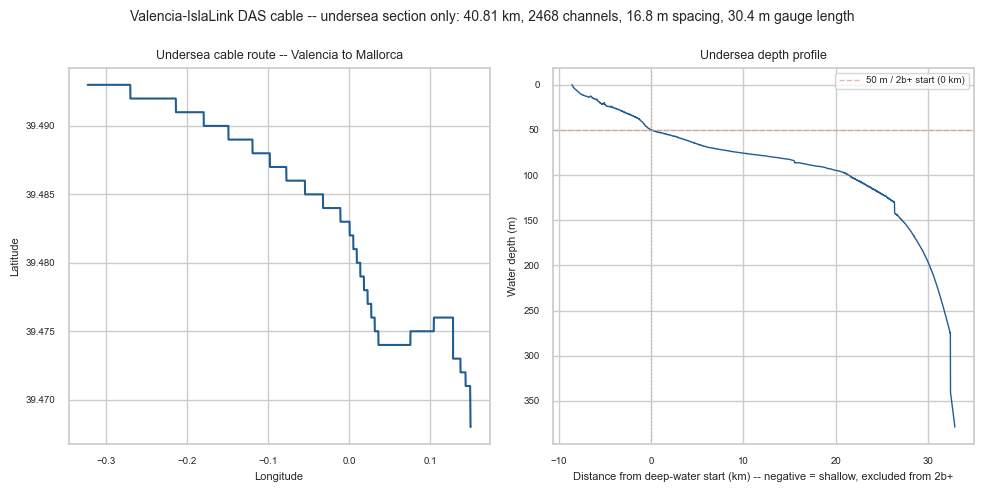

In [71]:
# --- 2a. Cable Geometry Overview (undersea only) ---
# This project only monitors the submarine portion of the cable (per the business
# case in CLAUDE.md: "submarine power-cable health monitoring") -- the onland
# portion is dropped everywhere from here on, not just in this plot.
UNDERSEA_LENGTH_M = 40811  # m -- pubDAS_data/readme.txt (cable length minus onland)

_geom_probe = load_h5_file(list_event_files(data_dir, EXAMPLE_EVENT)[0], channels=0)
GAUGE_LENGTH_M = _geom_probe.gauge_length
CHANNEL_SPACING_M = _geom_probe.channel_spacing

with h5py.File(list_event_files(data_dir, EXAMPLE_EVENT)[0], "r") as _f:
    _dev = list(_f.keys())[0]
    _n_channels_total = _f[f"{_dev}/Source1/Zone1/SR_Valencia"].shape[2]

# Undersea/onland boundary: the bundled geometry CSV is 1-indexed (its channel
# numbers run 510..2977, and 2977-510+1 = 2468 matches the CSV's unique-channel
# count exactly -- the HDF5 array only has valid 0-indexed positions 0..2976, so
# CSV channel 510 is 0-indexed position 509). Everything below loads/plots only
# UNDERSEA_FIRST_CHANNEL onward.
UNDERSEA_FIRST_CHANNEL = 509
N_CHANNELS = _n_channels_total - UNDERSEA_FIRST_CHANNEL

undersea_geo = pd.read_csv(_BASE_DIR / "pubDAS_data" / "DAS-1-geometry-Valencia-undersea.csv")

# From 2b onward we only look at water deeper than 50 m -- the shallow near-shore
# stretch (depth ~0-50 m) is real data but extremely noisy (port/coastal activity,
# see 2c) and not useful for vessel detection. Derived from the depth survey itself
# (first channel where depth crosses 50 m, confirmed monotonic just before the
# crossing -- not a one-off spike), not hardcoded, so it can't silently drift from
# the actual bathymetry.
_deep_water_csv_channel = undersea_geo.loc[undersea_geo["Depth (m)"] > 50, "Channel"].min()
DEEP_WATER_FIRST_CHANNEL = int(_deep_water_csv_channel) - 1  # CSV is 1-indexed (see UNDERSEA_FIRST_CHANNEL note above)

# Re-zero to the SAME reference point 2b onward uses (start of deep water, not the
# undersea section's own start) -- otherwise this plot's "0 km" and every later
# plot's "0 km" would mean different things. Shallow water (<50 m, excluded from
# 2b+) shows up here as negative distance.
undersea_dist_km = (undersea_geo["Channel"].to_numpy() - _deep_water_csv_channel) * CHANNEL_SPACING_M / 1000

fig, axes = plt.subplots(1, 2, figsize=FigSize.WIDE)

ax = axes[0]
ax.plot(undersea_geo["Longitude"], undersea_geo["Latitude"], color=BLUE_2, lw=1.5)
ax.set_xlabel("Longitude", fontsize=8)
ax.set_ylabel("Latitude", fontsize=8)
ax.set_title("Undersea cable route -- Valencia to Mallorca", fontsize=9)
ax.tick_params(labelsize=7)
# No forced equal-aspect here: the route is long-and-thin enough (40.8 km of
# undersea cable inside ~0.5 degrees of longitude) that true geographic
# proportions leave most of the panel blank -- verified directly, this looked
# worse, not better. Clarity wins over geographic precision for this plot.

ax = axes[1]
ax.plot(undersea_dist_km, undersea_geo["Depth (m)"], color=BLUE_2, lw=1.0)
ax.axhline(50, color=DIV_2, ls='--', lw=1, alpha=0.7, label='50 m / 2b+ start (0 km)')
ax.axvline(0, color=DIV_2, ls=':', lw=1, alpha=0.5)
ax.invert_yaxis()
ax.set_xlabel("Distance from deep-water start (km) -- negative = shallow, excluded from 2b+", fontsize=8)
ax.set_ylabel("Water depth (m)", fontsize=8)
ax.set_title("Undersea depth profile", fontsize=9)
ax.legend(fontsize=7)
ax.tick_params(labelsize=7)

plt.suptitle(
    f"Valencia-IslaLink DAS cable -- undersea section only: {UNDERSEA_LENGTH_M/1000:.2f} km, "
    f"{N_CHANNELS} channels, {CHANNEL_SPACING_M} m spacing, {GAUGE_LENGTH_M} m gauge length",
    fontsize=10,
)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_cable_geometry.png', dpi=150)
plt.show()


In [72]:
# --- 2b. Load example event & interpolate bad channels (slow -- run once) ---
# Kept separate from filtering/windowing below: loading the full 10-minute record
# and detecting/interpolating bad channels doesn't depend on EDA_BANDPASS or
# EDA_WINDOW_SEC, so it shouldn't have to re-run every time those are tweaked.
# Loads from DEEP_WATER_FIRST_CHANNEL (set in 2a, depth > 50 m), not
# UNDERSEA_FIRST_CHANNEL -- the shallow 0-50 m stretch is real but too noisy to be
# useful here (see 2a's depth plot and 2c's waterfall for why).
example_file = list_event_files(data_dir, EXAMPLE_EVENT)[0]
eda_event = load_h5_file(example_file, channels=slice(DEEP_WATER_FIRST_CHANNEL, None))
distance_km = np.arange(eda_event.n_channels) * eda_event.channel_spacing / 1000  # 0 = start of deep water (>50 m)
full_raw = eda_event.strain_rate

# Bad-channel detection + interpolation: data_preprocess.detect_bad_channels()/
# interpolate_bad_channels() -- the same functions the batch extraction (3a-ii)
# and the flagged-window waterfall (Section 7) call, so all three code paths screen
# bad channels identically.
is_bad = detect_bad_channels(full_raw)
clean = interpolate_bad_channels(full_raw, is_bad)

print(f"Loaded {EXAMPLE_EVENT} / {example_file.name} (deep-water channels only, >50m: {eda_event.n_channels})")
print(f"Bad channels interpolated: {is_bad.sum()} / {len(is_bad)}")


Loaded SR_Valencia_2020-09-01_13-21-28_UTC / SR_Valencia_2020-09-01_13-21-28_UTC_10mins.h5 (deep-water channels only, >50m: 1959)
Bad channels interpolated: 2 / 1959


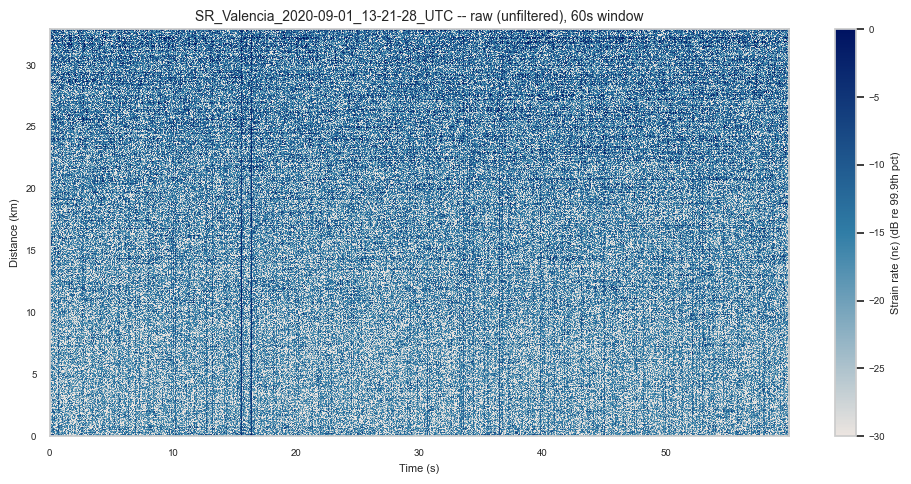

Window shown: 60 s, 1959 channels


In [73]:
# --- 2c. Raw waterfall (no filter) ---
# Bad-channel-cleaned but otherwise unfiltered -- shows what this hour actually
# looks like before any frequency-domain decisions get made (see 2e for the
# spectrum that the filter choice in 2g is actually based on). EDA_WINDOW_SEC
# now lives in Section 0b (used by several Section 2 cells, not just this one).
n_show = int(EDA_WINDOW_SEC * eda_event.fs)
raw_window = clean[:n_show, :]
time_s = np.arange(n_show) / eda_event.fs

fig, ax = plot_waterfall(
    raw_window, time_s, distance_km,
    title=f'{EXAMPLE_EVENT} -- raw (unfiltered), {EDA_WINDOW_SEC}s window',
    cbar_label='Strain rate (nε)',
)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_waterfall_raw.png', dpi=150)
plt.show()

print(f"Window shown: {EDA_WINDOW_SEC} s, {raw_window.shape[1]} channels")


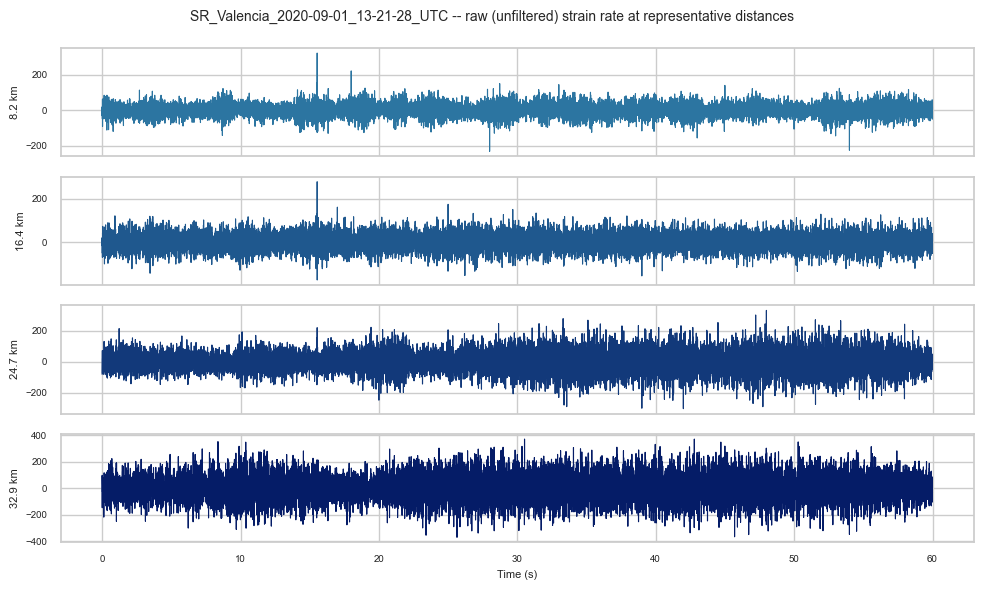

In [74]:
# --- 2d. Raw time-series at representative distances ---
# Same channels used by the spectrum in 2e (skipping the 0.0 km one, defined
# here and reused there) -- a direct look at what the raw (unfiltered),
# bad-channel-cleaned signal actually looks like over time at each distance,
# over the same EDA_WINDOW_SEC display window as 2c's waterfall.
_sample_channels = np.linspace(0, eda_event.n_channels - 1, 5, dtype=int)
_spectrum_colors = blues(len(_sample_channels), lo=0.4, hi=0.95)
_ts_channels = _sample_channels[1:]
_ts_colors = _spectrum_colors[1:]

fig, axes = plt.subplots(len(_ts_channels), 1, figsize=FigSize.MULTI_PANEL, sharex=True)
for ax, ch, color in zip(axes, _ts_channels, _ts_colors):
    ax.plot(time_s, raw_window[:, ch], color=color, lw=0.8)
    ax.set_ylabel(f'{distance_km[ch]:.1f} km', fontsize=8)
    ax.tick_params(labelsize=7)
axes[-1].set_xlabel('Time (s)', fontsize=8)
plt.suptitle(f'{EXAMPLE_EVENT} -- raw (unfiltered) strain rate at representative distances', fontsize=10)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_raw_timeseries.png', dpi=150)
plt.show()


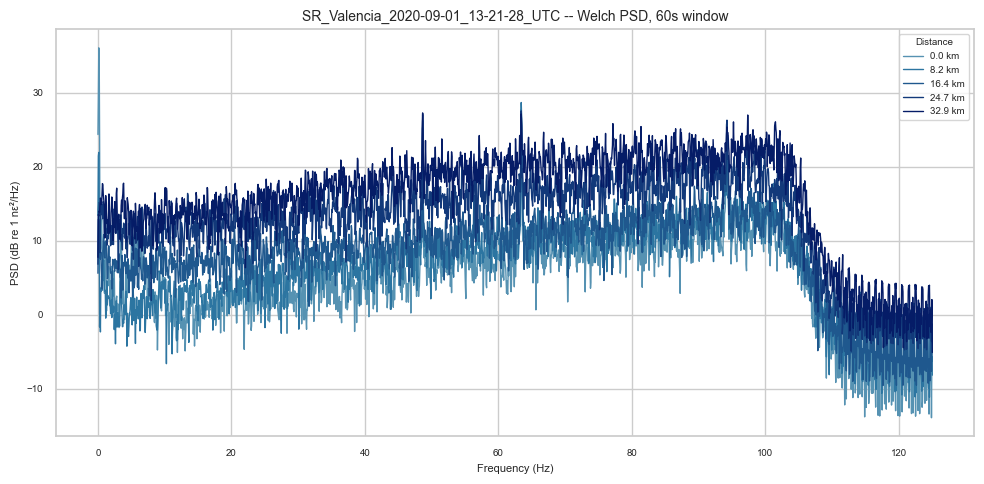

In [75]:
# --- 2e. Spectrum -- where is the energy? ---
# Welch PSD on a handful of channels spread across the undersea section,
# computed on the SAME EDA_WINDOW_SEC display window as 2c/2d/2k (not the
# full 10-minute record) -- consistent with the rest of Section 2, at the
# cost of a noisier PSD estimate (fewer Welch segments to average over 60s
# than over the full 10 minutes). This is what the bandpass choice in 2g is
# actually based on -- see for yourself where the energy concentrates in
# THIS hour, rather than just trusting the old README's documented band or
# the Matlab example's band.
# _sample_channels / _spectrum_colors are defined in 2d, reused here so both
# cells look at the exact same representative channels.

fig, ax = plt.subplots(figsize=FigSize.WIDE)
for ch, color in zip(_sample_channels, _spectrum_colors):
    f, pxx = welch(clean[:n_show, ch].astype(np.float64), fs=eda_event.fs, nperseg=4096)
    ax.plot(f, 10 * np.log10(pxx), color=color, lw=1.0, label=f'{distance_km[ch]:.1f} km')
ax.set_xlabel('Frequency (Hz)', fontsize=8)
ax.set_ylabel('PSD (dB re 1 nε²/Hz)', fontsize=8)
ax.set_title(f'{EXAMPLE_EVENT} -- Welch PSD, {EDA_WINDOW_SEC}s window', fontsize=10)
ax.legend(fontsize=7, title='Distance', title_fontsize=7)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_spectrum.png', dpi=150)
plt.show()


Channels with no valid data at all: 1 / 1959


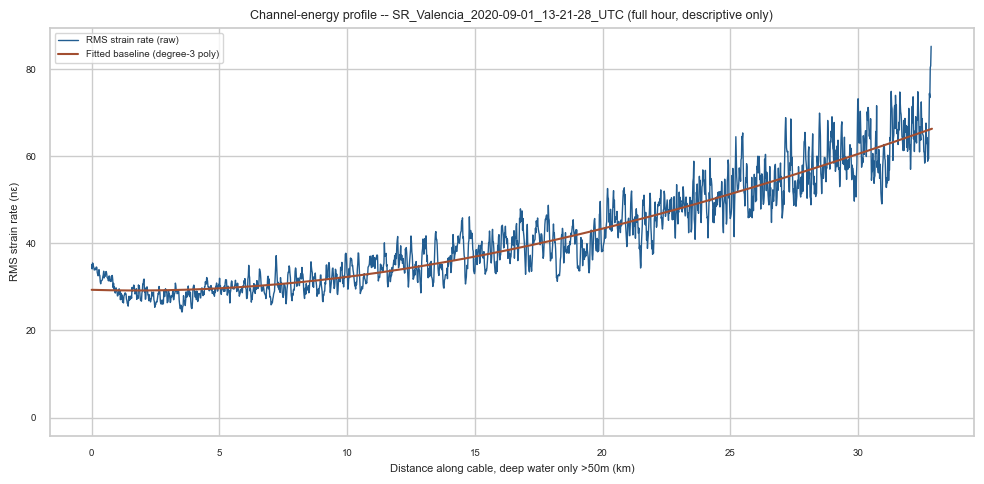

Lowest-energy channel : idx=1957 (32.89 km)
Highest-energy channel: idx=1956 (32.86 km)
(Descriptive only -- not used to select a channel for modelling; see CLAUDE.md.)


In [76]:
# --- 2f. Channel-energy profile + fitted distance-baseline curve ---
# Streams through each file in the event accumulating per-channel sum-of-squares,
# so memory use stays at one file at a time rather than the full hour --
# squares strain_rate IN PLACE (np.square(..., out=...)) rather than via
# strain_rate**2, which would allocate a full second same-sized temporary
# array (verified directly: this doubled peak memory for this cell alone,
# on top of everything else already resident in a long-running kernel
# session -- CLAUDE.md SS9/2g's own memory notes). valid_counts is computed
# BEFORE the in-place square, since NaN-ness would otherwise need re-deriving
# after squaring (NaN**2 is still NaN, but don't rely on that implicitly).
# Uses
# EXAMPLE_EVENT (the first downloaded hour, set in Section 1) -- the curve below
# is fit on this one hour; CLAUDE.md SS9 covers fitting on training events only
# once this becomes a real preprocessing step in the modelling pipeline.
# This is NOT "peak channel selection" -- there is no known event in this window,
# so picking "the loudest channel" here would just encode persistent background
# noise as if it were meaningful. See CLAUDE.md.
#
# At least one channel right at the cable's far end is entirely NaN/zero in the
# raw data -- structurally missing, not a computation bug -- so this accumulates
# per-channel valid-sample counts rather than assuming every channel has the same
# count, and leaves them as NaN in the final profile (a real gap), not silently
# propagated into channels that do have data.
event_files = list_event_files(data_dir, EXAMPLE_EVENT)
sumsq = None
valid_counts = None
for f in event_files:
    part = load_h5_file(f, channels=slice(DEEP_WATER_FIRST_CHANNEL, None))
    if sumsq is None:
        sumsq = np.zeros(part.n_channels)
        valid_counts = np.zeros(part.n_channels)
    valid_counts += np.sum(~np.isnan(part.strain_rate), axis=0)
    sumsq += np.nansum(np.square(part.strain_rate, out=part.strain_rate), axis=0, dtype=np.float64)

with np.errstate(invalid='ignore'):
    rms_profile = np.sqrt(sumsq / valid_counts)  # NaN where valid_counts == 0 -- a real gap, not a bug
_valid = np.isfinite(rms_profile)
n_missing = np.sum(~_valid)
print(f"Channels with no valid data at all: {n_missing} / {len(rms_profile)}")

# Smooth distance-baseline curve (CLAUDE.md SS9): fit on RMS (energy^0.5), not raw
# energy -- variance-stabilizing, and matches how the baseline-RMS finding is
# already documented (~2x RMS, not ~4x energy). BASELINE_CURVE_DEGREE is
# deliberately low so the curve tracks the broad monotonic distance trend without
# chasing the localised 48/63 Hz interference bump near the far end (that's a
# separate, notch-filter problem, not part of the baseline -- see CLAUDE.md SS9)
# or other narrow local features.
BASELINE_CURVE_DEGREE = 3
# IMPORTANT, found later (Section 4-5): this single raw-signal curve is NOT
# sufficient on its own to remove distance bias from the engineered features
# built on top of it -- crest/kurt/peakiness are scale-invariant ratios that
# ANY signal-level scaling can never touch (mathematically: peak/s over
# rms/s cancels the s), and band/wpd energies still carry residual distance
# correlation (|r| up to ~0.5) since different frequency bands attenuate
# differently, which one broadband curve can't capture per-band. The real
# fix is per-FEATURE (utils/anomaly_models.fit_distance_curves/
# apply_distance_curves, applied in Sections 4-5) -- this curve is still
# useful (gives features a head start, and 2k's waterfall below is a valid
# visualization), just not a complete fix by itself. See CLAUDE.md SS9.
_baseline_coeffs = np.polyfit(distance_km[_valid], rms_profile[_valid], deg=BASELINE_CURVE_DEGREE)
baseline_rms_curve = np.poly1d(_baseline_coeffs)  # callable: baseline_rms_curve(distance_km) -> fitted RMS

fig, ax = plt.subplots(figsize=FigSize.WIDE)
ax.plot(distance_km, rms_profile, color=BLUE_2, lw=1.0, label='RMS strain rate (raw)')
ax.plot(distance_km, baseline_rms_curve(distance_km), color=RED_2, lw=1.5,
        label=f'Fitted baseline (degree-{BASELINE_CURVE_DEGREE} poly)')
ax.set_xlabel('Distance along cable, deep water only >50m (km)', fontsize=8)
ax.set_ylabel('RMS strain rate (nε)', fontsize=8)
ax.set_title(f'Channel-energy profile -- {EXAMPLE_EVENT} (full hour, descriptive only)', fontsize=9)
ax.legend(fontsize=7)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_channel_energy_profile.png', dpi=150)
plt.show()

print(f"Lowest-energy channel : idx={np.argmin(rms_profile[_valid])} ({distance_km[_valid][np.argmin(rms_profile[_valid])]:.2f} km)")
print(f"Highest-energy channel: idx={np.argmax(rms_profile[_valid])} ({distance_km[_valid][np.argmax(rms_profile[_valid])]:.2f} km)")
print("(Descriptive only -- not used to select a channel for modelling; see CLAUDE.md.)")


In [77]:
# --- 2g. Detrend + bandpass filter + distance-baseline normalize (complete
# pipeline, fast -- re-run freely) ---
# Calls data_preprocess.preprocess_channels() -- the exact same function
# 3a-ii's batch extraction and Section 7's flagged-window waterfall call, so this
# EDA look and the real feature-extraction pipeline can't drift apart. Runs bad-channel screen + common-mode removal + detrend
# + bandpass + f-k apparent-velocity highpass + distance normalize as one
# call -- re-screening bad channels here is redundant since `clean` (2b)
# already had them interpolated, but harmless and cheap: this cell never
# re-reads from disk, so re-checking costs nothing.
# Only this cell (and 2h's f-k spectrum, 2i's processed time-series, 2j's
# processed spectrum, and 2k's waterfall plot, all of which read
# EDA_BANDPASS directly or plot `normalized`) need to re-run when tweaking EDA_BANDPASS -- 2b (load + bad-channel interpolation), 2c
# (window/raw waterfall), 2d (raw time-series), 2e (spectrum), and 2f
# (channel-energy profile + baseline curve) above stay untouched.
# EDA_BANDPASS now lives in Section 0b (used by 2g/2h/2k/2l/3a-ii/7b, not just here).

# Filtering + normalizing the FULL 10-minute record BEFORE slicing the display
# window (n_show, set in 2c) -- filtfilt's edge transients must land outside the
# window we look at, not inside it (verified directly: filtering only a sliced
# window put a visible artefact at the right edge of the plot).
full_normalized, _ = preprocess_channels(
    clean, eda_event.fs, EDA_BANDPASS, distance_km, baseline_rms_curve,
    channel_spacing=CHANNEL_SPACING_M, bad_channel_action="interpolate",
    fk_c_low=FK_C_LOW,
)
normalized = full_normalized[:n_show, :]

print(f"Filtered + normalized with EDA_BANDPASS={EDA_BANDPASS}")


Filtered + normalized with EDA_BANDPASS=(2, 124)


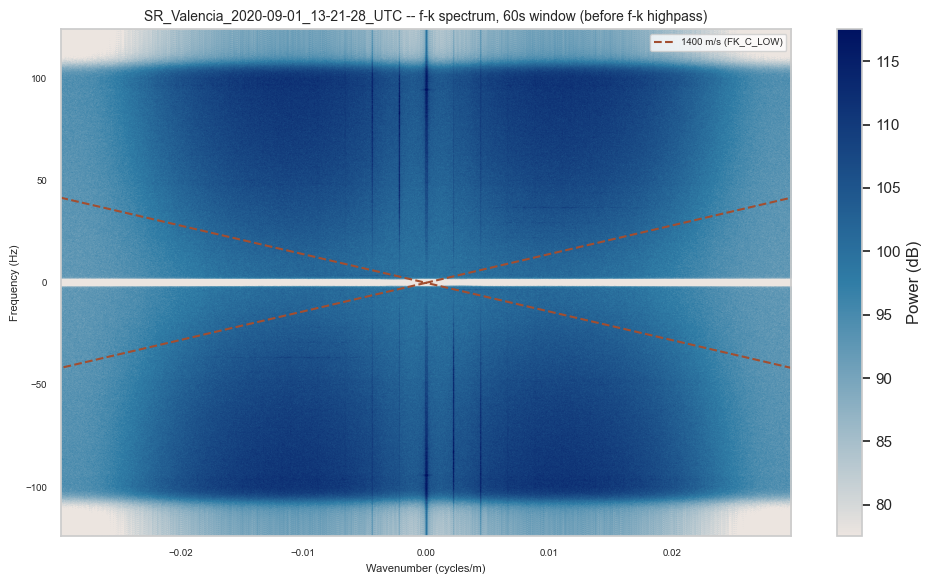

In [78]:
# --- 2h. f-k spectrum (2-D FFT) -- where does the FK_C_LOW apparent-velocity
# cutoff actually sit relative to this hour's real energy? Reference:
# old/DAS_Signal_Processing.ipynb's plot_fk_spectrum() -- reuses THIS
# project's own remove_common_mode()/detrend_bandpass() (the exact stages
# fk_filter() itself receives inside preprocess_channels(), CLAUDE.md SS9)
# rather than re-deriving them, and plots through plot_style.py (CLAUDE.md
# SS5) instead of the archived notebook's hardcoded colors.
# BEFORE the f-k highpass, not after -- shows what fk_filter() actually
# removes (everything below the reference lines), not just what survived it.
_fk_input = detrend_bandpass(remove_common_mode(clean), eda_event.fs, EDA_BANDPASS)[:n_show, :]
_n_t, _n_x = _fk_input.shape
_real_dtype = _fk_input.dtype

# Same taper/dtype care as fk_filter() (CLAUDE.md SS9): numpy.fft always
# upcasts to complex128 regardless of input dtype; scipy.fft is the one that
# actually preserves single precision -- and the taper/mask must be built in
# the signal's own dtype, not a hardcoded float64, or the upcast happens via
# the multiply instead. time_taper_sec=2.0 matches fk_filter()'s own default
# (an ABSOLUTE duration, not a fraction of the record -- CLAUDE.md SS9's
# edge-taper bug writeup).
_fk_tlen = max(1, min(int(2.0 * eda_event.fs), _n_t // 2))
_fk_ramp = (0.5 * (1 - np.cos(np.pi * np.arange(_fk_tlen) / _fk_tlen))).astype(_real_dtype)
_fk_taper = np.ones(_n_t, dtype=_real_dtype)
_fk_taper[:_fk_tlen] = _fk_ramp
_fk_taper[-_fk_tlen:] = _fk_ramp[::-1]
_fk_tapered = np.nan_to_num(_fk_input * _fk_taper[:, np.newaxis], nan=0.0)

_FK = sp_fft.fftshift(sp_fft.fft2(_fk_tapered))
_fk_freqs = sp_fft.fftshift(sp_fft.fftfreq(_n_t, d=1 / eda_event.fs))
_fk_wavenumbers = sp_fft.fftshift(sp_fft.fftfreq(_n_x, d=CHANNEL_SPACING_M))
_fk_db = 20 * np.log10(np.abs(_FK) + 1e-10)
_fk_vmax = np.percentile(_fk_db, 99.5)
_fk_vmin = _fk_vmax - 40  # 40 dB dynamic range, matches the archived notebook's default

fig, ax = plt.subplots(figsize=FigSize.MULTI_PANEL)
im = ax.imshow(
    _fk_db, aspect='auto', origin='lower',
    extent=[_fk_wavenumbers[0], _fk_wavenumbers[-1], _fk_freqs[0], _fk_freqs[-1]],
    cmap=CMAP_BLUE, vmin=_fk_vmin, vmax=_fk_vmax,
)
plt.colorbar(im, ax=ax, label='Power (dB)')

# Reference lines: apparent velocity c_app = |f| / |k| -> k = f / FK_C_LOW,
# both branches. Everything BELOW these lines (|c_app| < FK_C_LOW) is what
# fk_filter()'s highpass removes -- see fk_filter()'s docstring for why this
# is a highpass (near-field crossings span up to near-infinite apparent
# velocity), not a band.
_fk_k_ref = np.abs(_fk_freqs) / FK_C_LOW
ax.plot(_fk_k_ref, _fk_freqs, '--', lw=1.5, color=RED_2, label=f'{FK_C_LOW:.0f} m/s (FK_C_LOW)')
ax.plot(-_fk_k_ref, _fk_freqs, '--', lw=1.5, color=RED_2)

ax.set_xlim(-np.abs(_fk_wavenumbers).max(), np.abs(_fk_wavenumbers).max())
ax.set_ylim(-EDA_BANDPASS[1], EDA_BANDPASS[1])
ax.set_xlabel('Wavenumber (cycles/m)', fontsize=8)
ax.set_ylabel('Frequency (Hz)', fontsize=8)
ax.set_title(f'{EXAMPLE_EVENT} -- f-k spectrum, {EDA_WINDOW_SEC}s window (before f-k highpass)', fontsize=10)
ax.tick_params(labelsize=7)
ax.legend(loc='upper right', fontsize=7)
ax.grid(False)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_fk_spectrum.png', dpi=150)
plt.show()


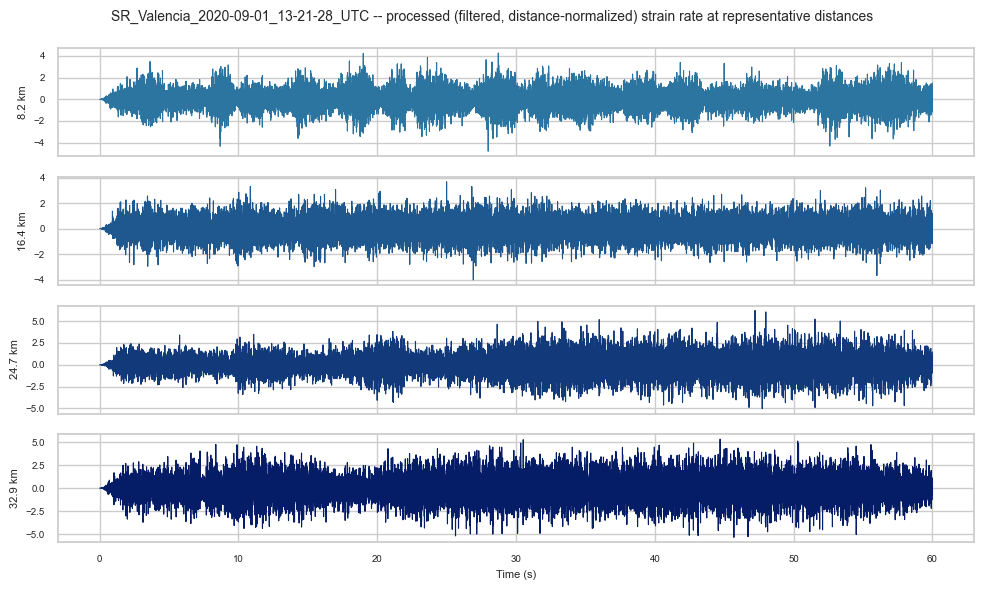

In [79]:
# --- 2i. Processed time-series at representative distances ---
# Same channels as 2d/2e (reused, not redefined) -- direct before/after
# comparison against 2d's raw view: what the fully processed (bad-channel-
# screened, common-mode-removed, detrended, bandpass-filtered, f-k
# highpass-filtered, distance-normalized) signal looks like at the same
# representative distances, over the same EDA_WINDOW_SEC display window.
fig, axes = plt.subplots(len(_ts_channels), 1, figsize=FigSize.MULTI_PANEL, sharex=True)
for ax, ch, color in zip(axes, _ts_channels, _ts_colors):
    ax.plot(time_s, normalized[:, ch], color=color, lw=0.8)
    ax.set_ylabel(f'{distance_km[ch]:.1f} km', fontsize=8)
    ax.tick_params(labelsize=7)
axes[-1].set_xlabel('Time (s)', fontsize=8)
plt.suptitle(f'{EXAMPLE_EVENT} -- processed (filtered, distance-normalized) strain rate at representative distances', fontsize=10)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_processed_timeseries.png', dpi=150)
plt.show()


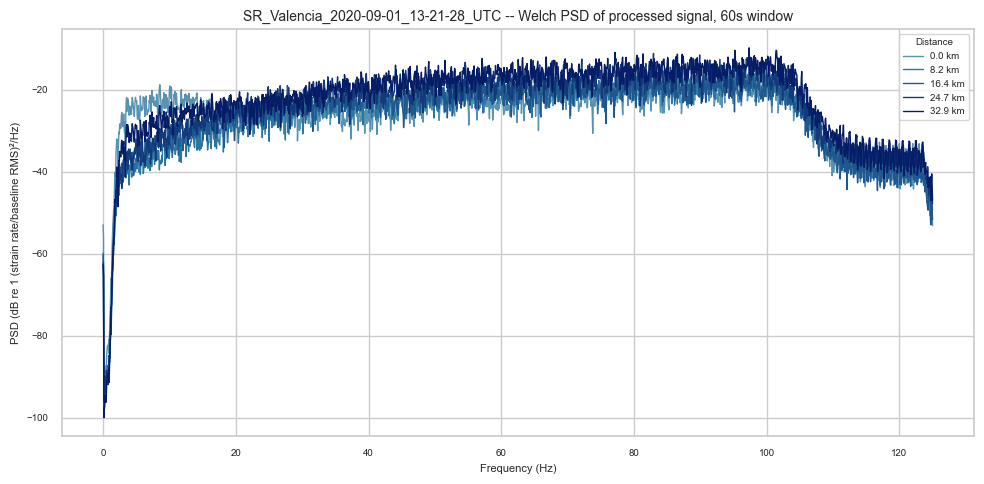

In [80]:
# --- 2j. Processed spectrum -- where is the energy now? ---
# Same channels and Welch recipe as 2e, applied to the processed (2g)
# signal instead of the raw (2b) one -- shows how common-mode removal +
# bandpass + f-k highpass (CLAUDE.md SS9) reshaped the spectrum relative
# to 2e's raw-signal view.
fig, ax = plt.subplots(figsize=FigSize.WIDE)
for ch, color in zip(_sample_channels, _spectrum_colors):
    f, pxx = welch(normalized[:, ch].astype(np.float64), fs=eda_event.fs, nperseg=4096)
    ax.plot(f, 10 * np.log10(pxx), color=color, lw=1.0, label=f'{distance_km[ch]:.1f} km')
ax.set_xlabel('Frequency (Hz)', fontsize=8)
ax.set_ylabel('PSD (dB re 1 (strain rate/baseline RMS)\u00b2/Hz)', fontsize=8)
ax.set_title(f'{EXAMPLE_EVENT} -- Welch PSD of processed signal, {EDA_WINDOW_SEC}s window', fontsize=10)
ax.legend(fontsize=7, title='Distance', title_fontsize=7)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_processed_spectrum.png', dpi=150)
plt.show()


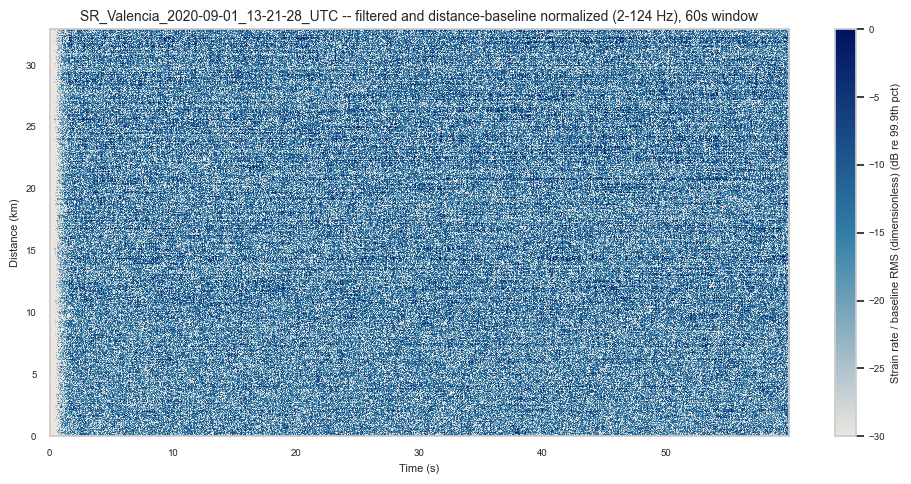

In [81]:
# --- 2k. Filtered waterfall: distance-baseline normalized ---
# `normalized` is already the fully preprocessed (bad-channel-screened,
# common-mode-removed, detrended, bandpass-filtered, f-k highpass-filtered,
# distance-normalized) signal computed by 2g's single preprocess_channels()
# call -- this cell only visualizes it. Dividing
# by the baseline RMS curve (rather than subtracting) makes sense because this
# signal is already zero-mean (bandpass filtered), so there's no DC offset to
# remove; what varies with distance is the AMPLITUDE/spread of the noise
# floor, not its mean. Dividing rescales each channel's amplitude against its
# own typical baseline, so a single colour scale stays meaningful across the
# whole distance range, instead of being dominated by the far end's inherently
# larger noise floor (CLAUDE.md SS9). This is a *visualisation* choice, distinct
# from CLAUDE.md SS9's feature-level guidance (mean-center engineered features,
# don't scale-divide by local std) -- that decision is about not suppressing a
# real anomaly's z-score for modelling; this one is about making an
# already-zero-mean raw waterfall visually readable across distance.

# Percentile clim + interpolation='nearest' rationale is documented once in
# plot_waterfall()'s definition (0d), not repeated at every call site.
fig, ax = plot_waterfall(
    normalized, time_s, distance_km,
    title=f'{EXAMPLE_EVENT} -- filtered and distance-baseline normalized '
          f'({EDA_BANDPASS[0]}-{EDA_BANDPASS[1]} Hz), {EDA_WINDOW_SEC}s window',
)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_waterfall_filtered.png', dpi=150)
plt.show()


## 2l. Processed Data Demonstration

Optional, off by default (`RUN_WATERFALL_DEMO`, CLAUDE.md SS13) -- independently
re-loads and preprocesses every downloaded event's deep-water channels,
`CHANNEL_STRIDE`-subsampled (same stride as 3a-ii's batch extraction, moved
to Section 0b so both can use it) and saves one strain-rate waterfall PNG
per minute, per event, purely for manual visual inspection -- a
different/denser cut than Section 7's single zoomed view (Section 7 stays full-density
since it's one file, not a whole event's worth). Placed at the end of
Section 2, not Section 3: it's a preprocessing/visualization step, not a
feature-extraction one, and has no dependency on anything Section 3 defines.
Was full-channel-density until a MemoryError in `fk_filter()`'s 2D FFT
(CLAUDE.md SS9) forced the same channel-subsampling 3a-ii already used for
compute reasons -- here it's for memory instead.


In [82]:
# --- 2l. Processed-data waterfall demonstration (optional) ---
# Standalone demo: re-loads + preprocesses every downloaded event's
# deep-water channels via data_preprocess.preprocess_channels() -- the same
# function 2g/3a-ii/7 call -- and saves one strain-rate waterfall PNG per
# minute, per event. CHANNEL_STRIDE-subsampled (Section 0b) -- was
# full-density until fk_filter()'s 2D FFT raised a MemoryError on a single
# 10-minute file at ~1959 channels (verified directly: a (1959, ~150000)
# complex128 intermediate is ~4.4 GiB, and this machine did not have that
# much contiguous memory available). Stride 5 cuts that to ~392 channels,
# proportionally shrinking every f-k intermediate.
# Processes ONE 10-MINUTE FILE AT A TIME (like 2g's baseline-curve loop, not
# load_event()'s whole-hour concatenation) -- even at CHANNEL_STRIDE
# subsampling, a full HOUR (~900K samples) at once is unnecessary here since
# each file is exactly 600s and minute buckets 0-9 never span a file
# boundary -- no cross-file stitching needed.
RUN_WATERFALL_DEMO = False  # opt-in (CLAUDE.md SS13), off by default
WATERFALL_EXPORT_DIR = PLOTS_DIR / "waterfalls_per_minute"

if RUN_WATERFALL_DEMO:
    WATERFALL_EXPORT_DIR.mkdir(exist_ok=True)
    _n_waterfalls_saved = 0
    for event_id in event_ids:
        _t0 = time.time()
        _event_start = datetime.strptime(
            re.search(r'(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})_UTC', event_id).group(1),
            "%Y-%m-%d_%H-%M-%S",
        )
        for file_idx, f in enumerate(list_event_files(data_dir, event_id)):
            file_event = load_h5_file(f, channels=slice(DEEP_WATER_FIRST_CHANNEL, None, CHANNEL_STRIDE))
            sr = file_event.strain_rate
            # Strided distance array (NOT 2b's full-density distance_km, which
            # has ~5x too many entries for this array's column count) -- same
            # analytic computation 3a-i uses for selected_channels_distance_km.
            distance_km_2k = np.arange(file_event.n_channels) * CHANNEL_STRIDE * CHANNEL_SPACING_M / 1000
            normalized_all, _ = preprocess_channels(
                sr, file_event.fs, EDA_BANDPASS, distance_km_2k,
                baseline_rms_curve, channel_spacing=CHANNEL_STRIDE * CHANNEL_SPACING_M,
                bad_channel_action="skip", fk_c_low=FK_C_LOW,
            )
            # bad_channel_action="skip", not "interpolate": strided "neighbours"
            # are CHANNEL_STRIDE * 16.8 m apart, not true physical neighbours
            # (same reasoning 3a-ii uses, CLAUDE.md SS8.4).

            _file_start = _event_start + timedelta(seconds=file_idx * 600)
            time_s_file = np.arange(sr.shape[0]) / file_event.fs
            n_minutes = int(time_s_file[-1] // 60) + 1
            for minute_idx in range(n_minutes):
                _mask = (time_s_file >= minute_idx * 60) & (time_s_file < (minute_idx + 1) * 60)
                if _mask.sum() < 30 * file_event.fs:  # skip a tiny leftover sliver
                    continue
                _minute_time = _file_start + timedelta(seconds=minute_idx * 60)
                _minute_signal = normalized_all[_mask]
                _minute_time_s = time_s_file[_mask]

                fig, ax = plot_waterfall(
                    _minute_signal, _minute_time_s, distance_km_2k,
                    title=_minute_time.strftime('%Y-%m-%d %H:%M:%S UTC'),
                )
                plt.tight_layout()
                plt.savefig(WATERFALL_EXPORT_DIR / f"{_minute_time.strftime('%Y-%m-%d_%H-%M-%S')}_UTC.png", dpi=150)
                plt.close(fig)  # not plt.show() -- many inline figures would be excessive
                _n_waterfalls_saved += 1

        print(f"  {event_id}: {time.time() - _t0:.0f}s elapsed")

    print(f"Saved {_n_waterfalls_saved} per-minute waterfalls to {WATERFALL_EXPORT_DIR}")
else:
    print("RUN_WATERFALL_DEMO=False -- skipping per-minute waterfall export")


RUN_WATERFALL_DEMO=False -- skipping per-minute waterfall export


## 3. Preprocessing Pipeline -- DSP Feature Extraction

Sliding-window feature extraction across every selected channel of every
downloaded event, building one feature matrix (`X_batch`) for modelling --
ported from `old/DAS_Signal_Processing.ipynb`'s "(i) FEATURE ENGINEERING --
Single Channel" cell: 7 hand-crafted features per window -- RMS, Peak, Crest
Factor, Kurtosis (time-domain), N-band Welch PSD energy (frequency-domain),
plus optional Wavelet Packet Decomposition sub-band energy (db4, level 3) if
`pywavelets` is installed. Bad-channel screen, common-mode removal, detrend +
bandpass, f-k highpass, and distance-baseline normalization already happened
in Section 2's `preprocess_channels()` calls -- this section is feature
extraction only, on signal that's already fully preprocessed.

(A single-channel demo used to precede the batch extraction below, plotting
one representative channel's features before the batch loop computed the
real thing -- removed as redundant once the batch loop existed; `X_batch`
below can be sliced to any one channel/event for the same kind of plot if
needed.)

Building `X` here means `X, event_ids` -- there is no `y`, no `conditions`
(see CLAUDE.md SS8.1).


## 3a. Batch Feature Extraction

Runs `extract_window_features()` across every selected channel of every
downloaded event, building one feature matrix for modelling. Configurable via
`CHANNEL_STRIDE` (1 = every channel, 2 = every other) -- window/hop
(`WINDOW_SEC`/`HOP_SEC`) scales mainly with `CHANNEL_STRIDE`
(channels x windows x events).

No `y`/`conditions` -- there are no labels for this dataset (CLAUDE.md SS8.1).
The result is cached locally (`.feature_cache_*.pkl`, gitignored) keyed on
every parameter that changes the output, so re-running this section doesn't
redo a ~30-minute extraction unless something relevant actually changed.

Raw features aren't directly comparable across channels without accounting
for the distance-dependent baseline (CLAUDE.md SS9) -- that's a
modelling-stage normalisation step, not done here.

Per-minute strain-rate waterfall export lives in Section 2l, not here --
it's a preprocessing/visualization step, not a feature-extraction one.


In [83]:
# --- 3a-i. Batch extraction parameters ---
# WINDOW_SEC, HOP_SEC, WPD_WAVELET, WPD_LEVEL, USE_WPD, and PSD_BANDS all now
# live in Section 0b (used by 3a-ii's batch loop, 6a-i/ii, and Section 7's
# screening, not just this cell -- CHANNEL_STRIDE made the same move earlier
# for the same reason).

# NOTE: deliberately eda_event.n_channels (the deep-water count, from
# DEEP_WATER_FIRST_CHANNEL onward), NOT 2a's N_CHANNELS -- that constant is
# paired with the larger UNDERSEA_FIRST_CHANNEL=509 section, not the
# deep-water-only one this notebook uses from 2b onward. Using N_CHANNELS here
# would select channel indices past the array's valid range.
N_DEEP_WATER_CHANNELS = eda_event.n_channels
selected_channels = DEEP_WATER_FIRST_CHANNEL + np.arange(0, N_DEEP_WATER_CHANNELS, CHANNEL_STRIDE)
# Per-channel distance, for the 2f/2k distance-baseline curve applied in 3a-ii --
# computed analytically (not by indexing into 2f's distance_km array) so it can't
# silently misalign if that array's indexing convention ever changes.
selected_channels_distance_km = (selected_channels - DEEP_WATER_FIRST_CHANNEL) * CHANNEL_SPACING_M / 1000
_events_to_process = discover_events(data_dir)
print(f"WINDOW_SEC={WINDOW_SEC}s / HOP_SEC={HOP_SEC}s")
print(f"PSD_BANDS: {[(round(lo, 1), round(hi, 1)) for lo, hi in PSD_BANDS]}")
print(f"USE_WPD: {USE_WPD}")
print(f"CHANNEL_STRIDE={CHANNEL_STRIDE} -> {len(selected_channels)} channels selected (of {N_DEEP_WATER_CHANNELS})")
print(f"Events to process: {_events_to_process}")


WINDOW_SEC=10s / HOP_SEC=5.0s
PSD_BANDS: [(2, 8), (8, 20), (20, 35), (35, 50), (50, 90), (90, 124)]
USE_WPD: True
CHANNEL_STRIDE=5 -> 392 channels selected (of 1959)
Events to process: ['SR_Valencia_2020-09-01_13-21-28_UTC', 'SR_Valencia_2020-09-01_14-21-29_UTC', 'SR_Valencia_2020-09-01_15-21-30_UTC', 'SR_Valencia_2020-09-01_16-21-31_UTC']


In [84]:
# --- 3a-ii. Batch extraction loop + local cache ---
# Loads each event ONCE (load_event() re-reads from disk per call). Detrend +
# bandpass + distance-baseline normalization are vectorized across all
# selected channels at once (not per-channel). Per-minute waterfall export
# used to be piggy-backed onto this loop -- it's now 2l's own independent
# (and independently toggleable) step, so this loop is feature-extraction only.
_dsp_src_hash = hashlib.md5(
    (_BASE_DIR / "utils" / "dsp_features.py").read_bytes() +
    (_BASE_DIR / "utils" / "data_preprocess.py").read_bytes()
).hexdigest()[:8]  # invalidates the cache if EITHER feature extraction or preprocessing changes
_cache_key = hashlib.md5(
    f"{sorted(_events_to_process)}{tuple(selected_channels.tolist())}{WINDOW_SEC}{HOP_SEC}"
    f"{PSD_BANDS}{WPD_WAVELET}{WPD_LEVEL}{USE_WPD}{EDA_BANDPASS}{_dsp_src_hash}"
    f"{tuple(baseline_rms_curve.coefficients)}v3".encode()
).hexdigest()[:12]
_cache_path = _BASE_DIR / f".feature_cache_{_cache_key}.pkl"

if _cache_path.exists():
    with open(_cache_path, "rb") as f:
        _cache = pickle.load(f)
    X_batch, event_ids, channel_ids, feature_names = (
        _cache["X"], _cache["event_ids"], _cache["channel_ids"], _cache["feature_names"]
    )
    print(f"Loaded cached features: {_cache_path.name}  (X_batch.shape={X_batch.shape})")
else:
    print(f"No cache found ({_cache_path.name}) -- extracting "
          f"(this can take a while at the defaults)...")
    X_parts, event_ids_parts, channel_ids_parts = [], [], []
    for event_id in _events_to_process:
        _t0 = time.time()
        event = load_event(data_dir, event_id, channels=selected_channels.tolist())
        sr = event.strain_rate

        # data_preprocess.preprocess_channels(): bad-channel screen + detrend +
        # bandpass + distance-baseline normalize, vectorized across all
        # selected channels at once -- the exact same function 2b/2g/2k's EDA
        # look and Section 7's flagged-window waterfall call, so this can't quietly
        # drift from them. bad_channel_action="skip" (not "interpolate"): strided
        # "neighbours" are CHANNEL_STRIDE * 16.8 m apart, not true physical
        # neighbours, so interpolating across that gap isn't a real fix
        # (CLAUDE.md SS8.4) -- flagged channels are excluded below instead.
        normalized_all, is_bad = preprocess_channels(
            sr, event.fs, EDA_BANDPASS, selected_channels_distance_km,
            baseline_rms_curve, channel_spacing=CHANNEL_STRIDE * CHANNEL_SPACING_M,
            bad_channel_action="skip", fk_c_low=FK_C_LOW,
        )

        for ci, ch_glob in enumerate(selected_channels):
            if is_bad[ci]:
                continue
            # Same distance-baseline normalization as 2k, applied before feature
            # extraction (CLAUDE.md SS9) -- safe because splits are always
            # chronological, so the curve (fit on the earliest event) never sees a
            # held-out test event during fitting.
            feats_ch, feature_names = extract_window_features(
                normalized_all[:, ci], event.fs, WINDOW_SEC, HOP_SEC,
                PSD_BANDS, WPD_WAVELET, WPD_LEVEL, USE_WPD,
            )
            X_parts.append(feats_ch)
            event_ids_parts.extend([event_id] * len(feats_ch))
            channel_ids_parts.extend([int(ch_glob)] * len(feats_ch))

        print(f"  {event_id}: {int(is_bad.sum())} bad channel(s) skipped, "
              f"{time.time() - _t0:.0f}s elapsed")

    X_batch = np.vstack(X_parts)
    event_ids = np.array(event_ids_parts)
    channel_ids = np.array(channel_ids_parts)

    # No y/conditions keys -- no labels exist for this dataset (CLAUDE.md SS8.1).
    with open(_cache_path, "wb") as f:
        pickle.dump({
            "X": X_batch, "event_ids": event_ids, "channel_ids": channel_ids,
            "feature_names": feature_names,
            "params": dict(
                CHANNEL_STRIDE=CHANNEL_STRIDE, WINDOW_SEC=WINDOW_SEC,
                HOP_SEC=HOP_SEC, PSD_BANDS=PSD_BANDS,
                WPD_WAVELET=WPD_WAVELET, WPD_LEVEL=WPD_LEVEL, USE_WPD=USE_WPD,
                EDA_BANDPASS=EDA_BANDPASS,
            ),
        }, f)
    print(f"Saved cache: {_cache_path.name}  (X_batch.shape={X_batch.shape})")


Loaded cached features: .feature_cache_f51ca5b56cbc.pkl  (X_batch.shape=(1128176, 19))


In [85]:
# --- 3a-iii. Sanity check ---

print(f"X_batch shape    : {X_batch.shape}")
print(f"Unique events    : {len(np.unique(event_ids))}")
print(f"Unique channels  : {len(np.unique(channel_ids))} (of {len(selected_channels)} selected)")
print(f"All finite       : {np.all(np.isfinite(X_batch))}")
print()
pd.DataFrame(X_batch[:5], columns=feature_names)


X_batch shape    : (1128176, 19)
Unique events    : 4
Unique channels  : 392 (of 392 selected)
All finite       : True



,rms,peak,crest,kurt,peakiness,band_2-8hz,band_8-20hz,band_20-35hz,band_35-50hz,band_50-90hz,band_90-124hz,wpd_0-15hz,wpd_15-31hz,wpd_31-46hz,wpd_46-62hz,wpd_62-78hz,wpd_78-93hz,wpd_93-109hz,wpd_109-125hz
0,0.715229,2.698150,3.772428,0.714109,3.095728,0.004107,0.001156,0.002232,0.003237,0.006640,0.003800,92.291546,74.146954,119.590368,194.866444,252.707827,357.844597,212.126056,10.466649
1,0.738368,2.749827,3.724195,0.257321,3.134741,0.005262,0.001212,0.002358,0.003255,0.007054,0.004194,101.435169,75.450587,134.067411,215.621478,274.152087,308.079856,257.536324,13.922893
2,0.780027,3.311762,4.245702,0.611947,4.435297,0.004281,0.001191,0.002191,0.003071,0.007413,0.004881,97.262140,80.599526,135.328422,208.677679,293.108033,350.982316,366.894497,13.106400
3,0.804005,3.311762,4.119083,0.672669,4.511293,0.005019,0.001370,0.002263,0.003404,0.007891,0.006221,99.277839,72.210373,143.398511,240.688755,310.852943,485.807564,318.647879,16.295918
4,0.799983,3.878321,4.848003,0.473947,3.729123,0.005884,0.001354,0.002060,0.003620,0.008355,0.005530,113.756263,83.863641,149.975764,251.310135,286.309204,377.277502,358.909353,16.395376


## 3b. Feature Distributions

**3b-i**: a histogram per feature, pooled across all events/channels in
`X_batch` (all 4 downloaded hours) -- a sanity check on the batch-extracted
feature matrix before modelling starts: looks for degenerate/constant
features, extreme skew, or obvious multi-modality (e.g. from the
distance-dependent baseline, CLAUDE.md SS9) before anything is trained on it.

**3b-ii**: the same features as 3D surfaces (time x distance x value) for one
representative event (`EXAMPLE_EVENT`) -- time only has one coherent meaning
within a single event, unlike 3b-i's pooled view.

Both descriptive only, same spirit as 2f/2k -- not a model output, nothing
here is an anomaly score.


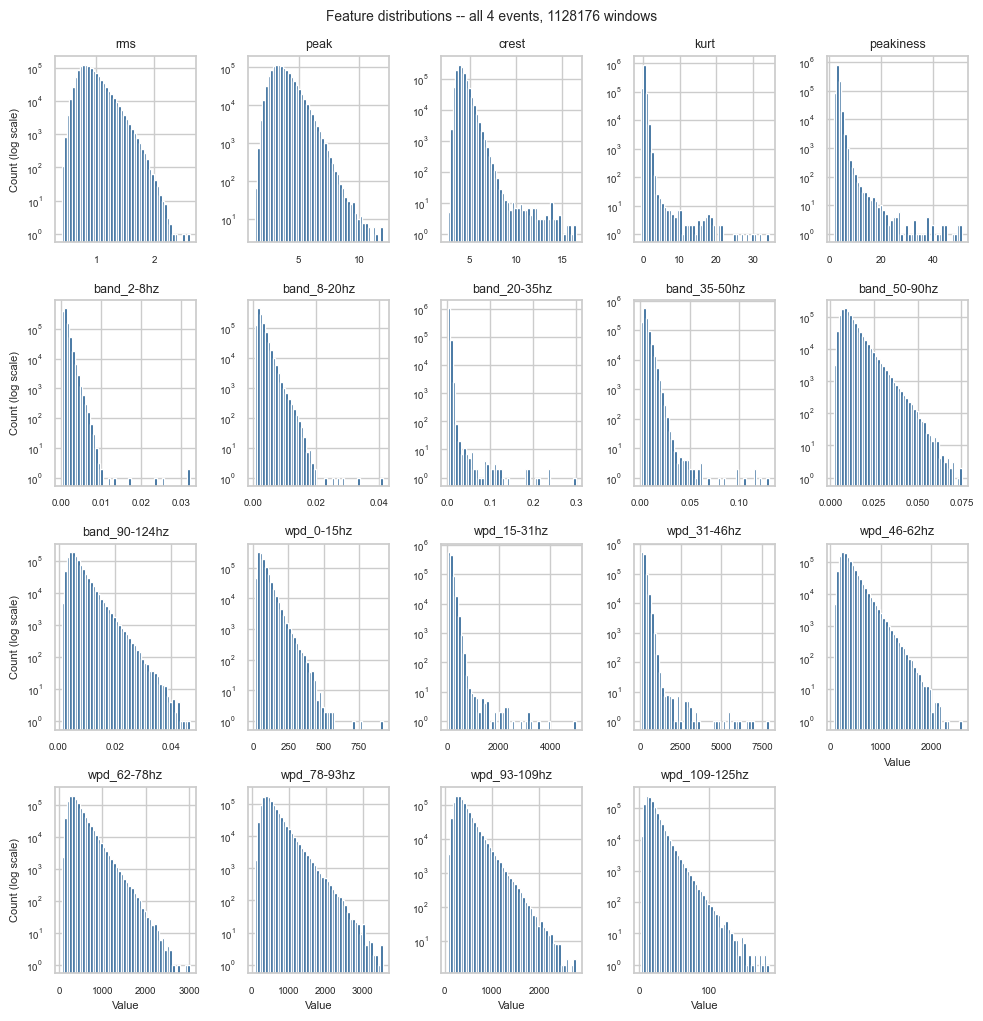

In [86]:
# --- 3b-i. Feature distribution histograms (all events/channels) ---
n_features = X_batch.shape[1]
n_cols = 5
n_rows = int(np.ceil(n_features / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(FigSize.MULTI_PANEL[0], 2.6 * n_rows))
axes = axes.ravel()

for fi in range(n_features):
    ax = axes[fi]
    ax.hist(X_batch[:, fi], bins=50, color=BLUE_2)
    # log-scale y-axis -- a heavy-tailed feature's rare extreme-value bins
    # (e.g. a few hundred rows out of >1M) are real but invisible on a
    # linear y-axis next to a peak bin in the hundreds of thousands; log
    # scale makes both visible at once without discarding/clipping any data.
    ax.set_yscale('log')
    ax.set_title(feature_names[fi], fontsize=9)
    ax.tick_params(labelsize=7)
    if fi % n_cols == 0:
        ax.set_ylabel('Count (log scale)', fontsize=8)
    if fi >= n_features - n_cols:
        ax.set_xlabel('Value', fontsize=8)

for fi in range(n_features, len(axes)):
    axes[fi].axis('off')

plt.suptitle(f'Feature distributions -- all {len(np.unique(event_ids))} events, '
             f'{X_batch.shape[0]} windows', fontsize=10)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'feature_distributions.png', dpi=150)
plt.show()


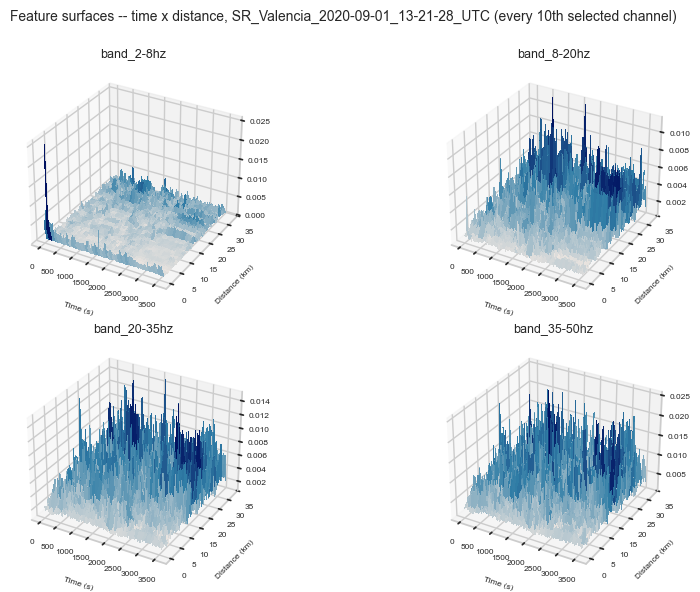

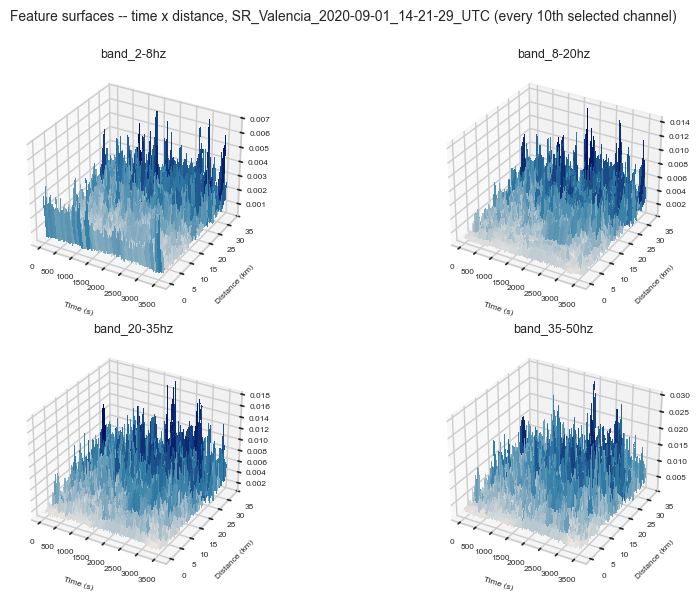

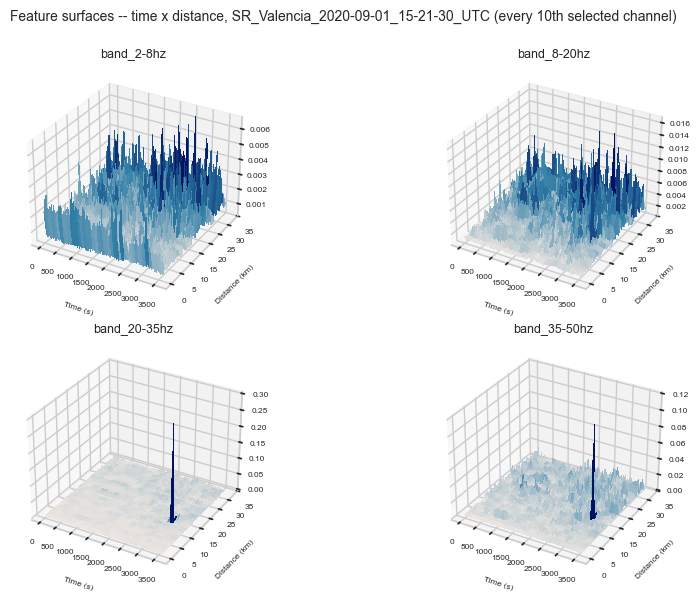

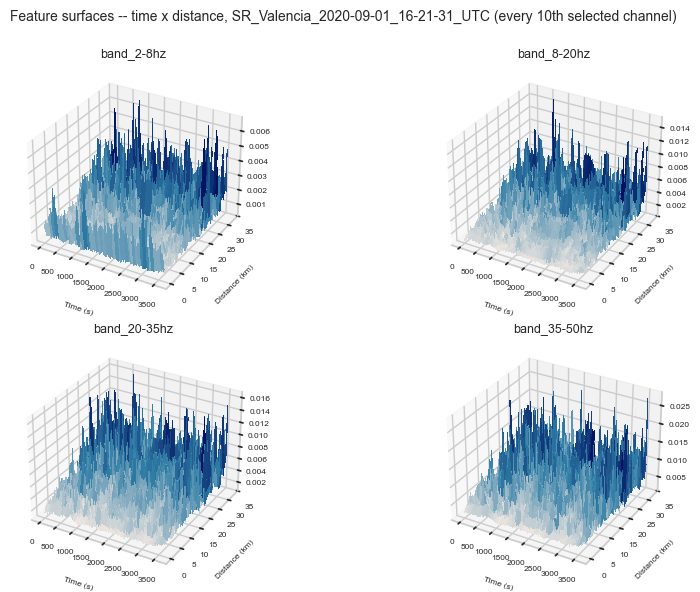

In [87]:
# --- 3b-ii. Feature surfaces: time x distance x value (per event) ---
# One figure per event (4 total) instead of one shared figure across all
# features and a single representative event -- time only has one coherent
# meaning within a single event (same reasoning as before), and this
# narrows the previous 19-feature grid down to just the 4 lowest PSD bands
# (2-8/8-20/20-35/35-50 Hz), the vessel-relevant range PSD_BANDS was
# designed around (CLAUDE.md SS9) -- not the pooled-across-events view
# 3b-i uses for histograms.
_surface_bands = ["band_2-8hz", "band_8-20hz", "band_20-35hz", "band_35-50hz"]
_surface_band_idx = [feature_names.index(b) for b in _surface_bands]

# Stride the channel axis for tractable rendering -- full channel count x
# full window count would be slow and visually solid/unreadable at this
# subplot size anyway.
PLOT3D_CHANNEL_STRIDE = 10

for _surface_event in sorted(np.unique(event_ids)):
    _event_mask = event_ids == _surface_event
    _event_channels = channel_ids[_event_mask]
    _unique_channels_event = np.unique(_event_channels)  # sorted ascending
    _n_channels_event = len(_unique_channels_event)
    _n_windows_event = _event_mask.sum() // _n_channels_event

    # X_batch rows are channel-major within one event (3a-ii's loop appends
    # one channel's full window sequence before moving to the next) -- this
    # reshape relies on that ordering, not on re-sorting by channel_ids.
    _X_event = X_batch[_event_mask].reshape(_n_channels_event, _n_windows_event, n_features)

    _time_grid_1d = np.arange(_n_windows_event) * HOP_SEC + WINDOW_SEC / 2
    _distance_grid_1d = (_unique_channels_event - DEEP_WATER_FIRST_CHANNEL) * CHANNEL_SPACING_M / 1000
    _distance_grid_1d_ds = _distance_grid_1d[::PLOT3D_CHANNEL_STRIDE]
    _X_event_ds = _X_event[::PLOT3D_CHANNEL_STRIDE]
    _T, _D = np.meshgrid(_time_grid_1d, _distance_grid_1d_ds)

    fig = plt.figure(figsize=FigSize.MULTI_PANEL)
    for bi, (band_name, fi) in enumerate(zip(_surface_bands, _surface_band_idx)):
        ax = fig.add_subplot(2, 2, bi + 1, projection="3d")
        ax.plot_surface(_T, _D, _X_event_ds[:, :, fi], cmap=CMAP_BLUE, linewidth=0, antialiased=False)
        ax.set_title(band_name, fontsize=9)
        ax.set_xlabel("Time (s)", fontsize=6, labelpad=0)
        ax.set_ylabel("Distance (km)", fontsize=6, labelpad=0)
        ax.tick_params(labelsize=6, pad=0)

    plt.suptitle(f"Feature surfaces -- time x distance, {_surface_event} "
                 f"(every {PLOT3D_CHANNEL_STRIDE}th selected channel)", fontsize=10)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"feature_surfaces_3d_{_surface_event}.png", dpi=150)
    plt.show()


## 4. Model Definition

`AnomalyDetectionPipeline` (defined in `utils/anomaly_models.py`) registers
**Isolation Forest**, a one-class unsupervised model, wrapped in a
`sklearn.Pipeline([("scaler", StandardScaler()), ("model", clf)])` so the
scaler is re-fit inside every fold. No parallel supervised branch (CLAUDE.md
SS3) -- there are no labels anywhere in this dataset.

**One-Class SVM was tried and dropped, not adapted.** Its libsvm-backed fit
had to be subsampled (5000 of ~846K training rows) for tractable runtime,
and the resulting model correlated weakly with both Isolation Forest and
the independent hand-crafted baseline detector (Spearman rho ~0.58, vs
~0.92 between Isolation Forest and the baseline) -- more consistent with
subsampling noise than a second real signal, and this project isn't
ML-architecture-focused enough to justify chasing that gap (e.g. raising
the subsample size, which reintroduces the runtime problem it was added to
avoid). See `utils/anomaly_models.py`'s module docstring for the full
history. Section 5 now compares Isolation Forest against the baseline
detector directly (CLAUDE.md SS9) instead of ensembling two ML models.

This replaced `utils/ml_classification.py`'s `TraditionalMLPipeline`
(RF/GBT/XGBoost, file since deleted) -- a clean replacement, not an
adaptation; nothing in that module's fitting/evaluation logic applied
without labels.

Hyperparameters are fixed values, not a search grid -- there is no label-based
score to select a "best" candidate against (CLAUDE.md SS9), so building grid-
search machinery here would have nothing real to optimize.

(The train/test split used throughout the rest of this notebook is
documented in Section 5, next -- chronological and fixed, no dedicated
cross-validation section any more, see that entry for why.)


In [88]:
# =========================================================
# 4. Model Definition
# =========================================================
# Per-row distance, used by fit_distance_curves()/apply_distance_curves()
# (Section 5) to decorrelate each feature from distance before fitting --
# the raw-signal-level correction (2f) alone leaves a strong residual
# distance bias in flag predictions, verified directly (CLAUDE.md SS9).
distance_km_all = (channel_ids - DEEP_WATER_FIRST_CHANNEL) * CHANNEL_SPACING_M / 1000

# IF_N_ESTIMATORS/IF_CONTAMINATION now live in Section 0b (used by this
# cell's registration print, 5a's final fit, and 6b's MLflow logging, not
# just here). ANOMALY_CONTAMINATION (an assumed-fraction guess that nothing
# ever read, kept only "for documentation purposes") deleted outright, not
# moved -- dead code, not a global constant.
pipeline_runner = AnomalyDetectionPipeline(
    if_n_estimators=IF_N_ESTIMATORS, if_contamination=IF_CONTAMINATION,
    random_state=RANDOM_STATE,
)
print("Models registered:")
for name in pipeline_runner.pipelines:
    print(f"  {name}")


Models registered:
  IsolationForest


## 5. Final Evaluation

Renamed from "Final Train / Test Evaluation" -- there is no held-out
*labelled* test set in the classification sense (CLAUDE.md SS3).

**Split: chronological, fixed, no cross-validation.** The 3 earliest
downloaded event-hours are the training set; the most recent (4th) hour is
the held-out test set -- the real forward-looking holdout matching the
deployment scenario (CLAUDE.md SS9's "always chronological, never random"
rule). A dedicated walk-forward CV section used to sit here (formerly
Section 5) demonstrating this same splitting mechanism across 3 folds at
fixed hyperparameters -- removed: there is no label-based score to select a
"best" hyperparameter candidate against (CLAUDE.md SS9), so despite its
former title it was never doing real model selection, and repeating the
same split mechanism across folds added little beyond what this section's
single, real split already shows.

**No ground truth anywhere in this dataset.** Every number below is one of
CLAUDE.md SS9's proxy evaluation methods -- inter-model/baseline agreement --
never precision, recall, F1, or accuracy (CLAUDE.md SS15 #9).


In [89]:
# =========================================================
# 5. Final Evaluation
# =========================================================
# --- 5a. Final chronological split: train on 3 earliest events, test on latest ---
event_ids_sorted = sorted(np.unique(event_ids).tolist())
print(f"Events (chronological): {event_ids_sorted}")

train_events_final, test_event_final = event_ids_sorted[:-1], event_ids_sorted[-1]
train_mask_final = np.isin(event_ids, train_events_final)
test_mask_final = event_ids == test_event_final

# Decorrelate each feature from distance (mean AND scale, fit on training
# rows only) before fitting -- see CLAUDE.md SS9's distance-baseline
# normalization discussion. X_train_final/X_test_final from here on are
# distance-decorrelated residuals, not the raw feature values in X_batch.
distance_curves_final = fit_distance_curves(
    X_batch[train_mask_final], distance_km_all[train_mask_final], feature_names
)
X_train_final = apply_distance_curves(X_batch[train_mask_final], distance_km_all[train_mask_final], distance_curves_final)
X_test_final = apply_distance_curves(X_batch[test_mask_final], distance_km_all[test_mask_final], distance_curves_final)
print(f"Train events: {train_events_final} ({X_train_final.shape[0]} rows)")
print(f"Test event  : {test_event_final} ({X_test_final.shape[0]} rows)")

final_pipeline = AnomalyDetectionPipeline(
    if_n_estimators=IF_N_ESTIMATORS, if_contamination=IF_CONTAMINATION,
    random_state=RANDOM_STATE,
)
final_pipeline.fit(X_train_final)
# anomaly_scores (continuous, higher = more anomalous) is the primary output
# of this section -- no is_anomaly_pred/flag rate here any more (CLAUDE.md
# SS9: no assumed anomaly rate to threshold on that isn't itself a guess).
anomaly_scores = final_pipeline.score(X_test_final)
print(f"IF score   : mean={anomaly_scores['IsolationForest'].mean():.4f}  std={anomaly_scores['IsolationForest'].std():.4f}")


Events (chronological): ['SR_Valencia_2020-09-01_13-21-28_UTC', 'SR_Valencia_2020-09-01_14-21-29_UTC', 'SR_Valencia_2020-09-01_15-21-30_UTC', 'SR_Valencia_2020-09-01_16-21-31_UTC']
Train events: ['SR_Valencia_2020-09-01_13-21-28_UTC', 'SR_Valencia_2020-09-01_14-21-29_UTC', 'SR_Valencia_2020-09-01_15-21-30_UTC'] (845936 rows)
Test event  : SR_Valencia_2020-09-01_16-21-31_UTC (282240 rows)
IF score   : mean=-0.0708  std=0.0529


### 5b. Baseline: hand-crafted z-score/L2-norm detector

Ported from `old/DAS_Signal_Processing.ipynb` cell 7 (`ANOMALY_THRESH = 2.5`
on `norm(z, L2)` over 7 hand-picked features -- even commented "replace with
Isolation Forest ... for unsupervised use"). Generalized here to all 19
features in `feature_names`.

Kept as a **continuous** score, not thresholded to a flag rate -- the fixed
`2.5` threshold doesn't transfer across feature counts anyway (under pure
noise the expected L2-norm of independent z-scores grows as
`sqrt(n_features)`, ~2.65 at the archived notebook's 7 dims vs ~4.36 at our
19), and a training-percentile cutoff would just reintroduce the same
guessed-rate problem Section 5a already moved away from. 5c instead
correlates this continuous score against Isolation Forest's (Section 5c) -- no second ML model to correlate against any more, One-Class SVM was dropped (CLAUDE.md SS4/SS9).


In [90]:
# --- 5b. Baseline: hand-crafted z-score/L2-norm detector ---
_train_mean = X_train_final.mean(axis=0)
_train_std = X_train_final.std(axis=0) + 1e-30
baseline_score = np.linalg.norm((X_test_final - _train_mean) / _train_std, axis=1)
anomaly_scores["Baseline"] = baseline_score
print(f"Baseline score: mean={baseline_score.mean():.4f}  std={baseline_score.std():.4f}")


Baseline score: mean=3.8274  std=2.1355


### 5c. Rank correlation (CLAUDE.md SS9 -- not accuracy/precision/recall)

Spearman rank correlation between Isolation Forest and the independent,
non-ML baseline detector's CONTINUOUS scores -- not a boolean agreement
rate, so it needs no assumed anomaly-rate threshold at all. High
correlation is weak evidence both are picking up a real shared signal; low
correlation flags that at least one is unreliable or the feature space
doesn't separate cleanly. **Still not a precision/recall number.** (One
comparison now, not three -- One-Class SVM was dropped, see md-sec4.)


In [91]:
# --- 5c. Rank correlation ---
results = {}
_model_names = list(anomaly_scores.keys())
for i, name_a in enumerate(_model_names):
    for name_b in _model_names[i + 1:]:
        rho, pval = spearmanr(anomaly_scores[name_a], anomaly_scores[name_b])
        results[f"{name_a} vs {name_b}"] = {"spearman_rho": float(rho), "p_value": float(pval)}
        print(f"spearman {name_a:16s} vs {name_b:16s}: rho={rho:.4f} (p={pval:.2e})")

print("\nNo ground truth anywhere in this dataset (CLAUDE.md SS1, SS9) -- the "
      "numbers above are rank correlations between unsupervised detectors' "
      "continuous scores, not accuracy, precision, recall, or F1 against any "
      "real label.")


spearman IsolationForest  vs Baseline        : rho=0.9167 (p=0.00e+00)

No ground truth anywhere in this dataset (CLAUDE.md SS1, SS9) -- the numbers above are rank correlations between unsupervised detectors' continuous scores, not accuracy, precision, recall, or F1 against any real label.


## 6. Visualisations

No labels anywhere in this dataset -- no confusion matrix, no ROC curve, no
Precision/Recall annotation (all of those need a true label to compare
against, CLAUDE.md SS1/SS9). What *can* be visualised is what Section 5
already computed: continuous `anomaly_scores` (Isolation Forest + the
baseline detector) for the held-out test event (`test_event_final`) -- no
binary `is_anomaly_pred`/flag rate any more (CLAUDE.md SS9: a fixed
contamination rate is itself an unverifiable guess, so the notebook now
reports rankings/continuous scores wherever possible).

**6a -- Mean anomaly score, two complementary views**: **6a-i** averages
across channels per time-window (shows *when* scores rise); **6a-ii**
averages across time windows per channel/distance instead (shows *where*
along the cable scores tend to be higher). Both min-max normalized per
detector for visual comparability only, not an absolute-magnitude claim --
neither is a flag count.

**6b -- MLflow logging**: kept in its existing sub-letter placement
(CLAUDE.md SS3) even though it isn't strictly a visualisation -- logs score
statistics and rank correlation instead of flag rates/agreement rates.

The spatial waterfall + candidate screening previously lettered "7b" here is
now its own top-level section (Section 7, next) -- it does real filtering
work (spatially-coherent cluster detection over a score threshold to pick
out candidates worth attention), not just plotting, so it no longer belongs
as a Visualisations sub-letter (CLAUDE.md SS4).


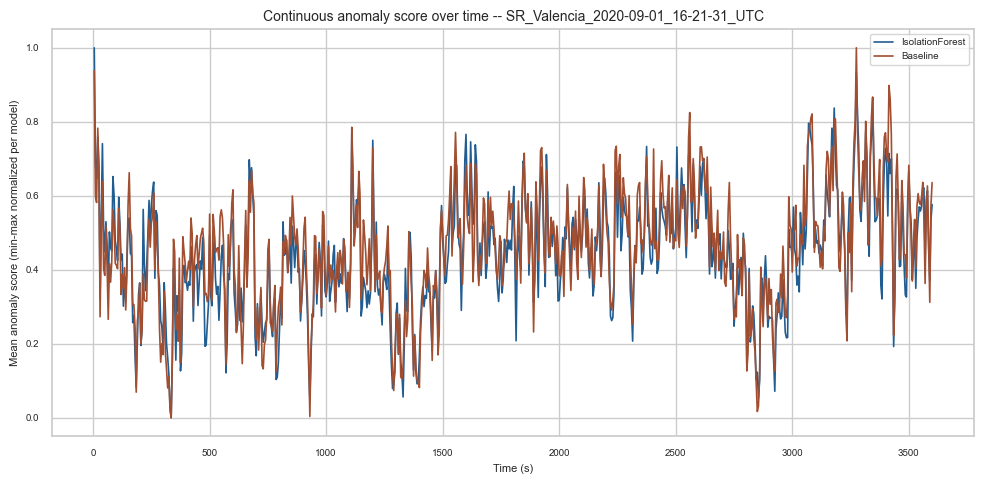

In [92]:
# =========================================================
# 6. Visualisations
# =========================================================
# --- 6a-i. Mean anomaly score over time, averaged across channels (test event) ---
_test_mask = event_ids == test_event_final
_test_channels = channel_ids[_test_mask]
_unique_channels_test = np.unique(_test_channels)
_n_channels_test = len(_unique_channels_test)
_n_windows_test = _test_mask.sum() // _n_channels_test
_t_mid_test = np.arange(_n_windows_test) * HOP_SEC + WINDOW_SEC / 2

# Fixed named colors, not divs()-sampled -- with exactly two detectors
# (Isolation Forest, Baseline) a gradient sample isn't needed; BLUE_2/RED_2
# match how simple two-way comparisons are colored elsewhere in this notebook.
_score_colors = {"IsolationForest": BLUE_2, "Baseline": RED_2}

fig, ax = plt.subplots(figsize=FigSize.WIDE)
for name in anomaly_scores:
    color = _score_colors.get(name, BLUE_2)
    score_grid = anomaly_scores[name].reshape(_n_channels_test, _n_windows_test)
    _profile = score_grid.mean(axis=0)
    # Min-max normalized PER MODEL, using only this profile's own range --
    # models' raw scores live on very different scales (e.g. Baseline's
    # L2-norm vs IF's decision_function), so this is for visual shape
    # comparison only, not a claim any two models' values are equivalent.
    _profile_norm = (_profile - _profile.min()) / (_profile.max() - _profile.min() + 1e-12)
    ax.plot(_t_mid_test, _profile_norm, lw=1.2, label=name, color=color)
ax.set_xlabel('Time (s)', fontsize=8)
ax.set_ylabel('Mean anomaly score (min-max normalized per model)', fontsize=8)
ax.set_title(f'Continuous anomaly score over time -- {test_event_final}', fontsize=10)
ax.legend(fontsize=7)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'anomaly_score_timeline.png', dpi=150)
plt.show()


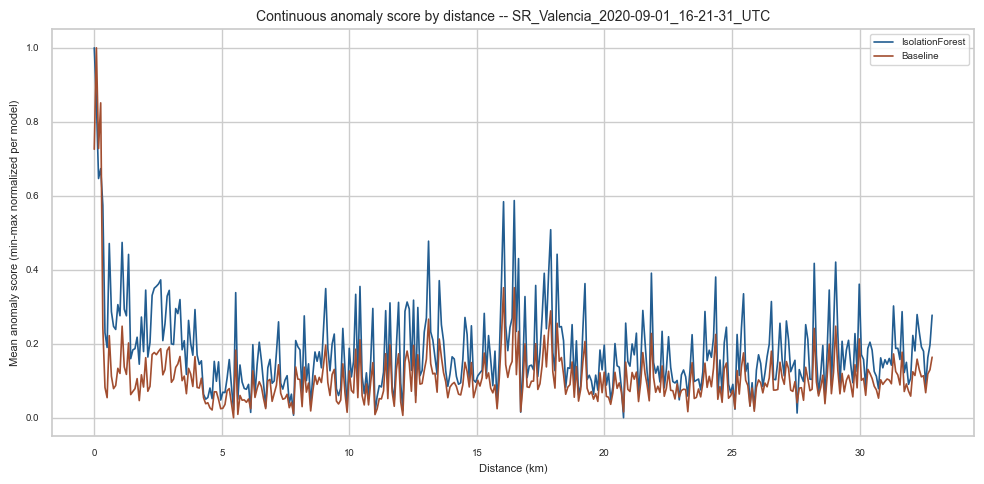

In [93]:
# --- 6a-ii. Mean anomaly score by distance, averaged across time (test event) ---
# Complements 7a-i: 7a-i averages over channels to see WHEN scores rise;
# this averages over time windows instead to see WHERE (which distance)
# tends to score higher across the whole held-out event -- the same
# min-max-per-model normalization convention as 7a-i, for the same reason
# (models live on very different raw scales).
distance_km_test = (_unique_channels_test - DEEP_WATER_FIRST_CHANNEL) * CHANNEL_SPACING_M / 1000

fig, ax = plt.subplots(figsize=FigSize.WIDE)
for name in anomaly_scores:
    color = _score_colors.get(name, BLUE_2)
    score_grid = anomaly_scores[name].reshape(_n_channels_test, _n_windows_test)
    _profile_km = score_grid.mean(axis=1)
    _profile_km_norm = (_profile_km - _profile_km.min()) / (_profile_km.max() - _profile_km.min() + 1e-12)
    ax.plot(distance_km_test, _profile_km_norm, lw=1.2, label=name, color=color)
ax.set_xlabel('Distance (km)', fontsize=8)
ax.set_ylabel('Mean anomaly score (min-max normalized per model)', fontsize=8)
ax.set_title(f'Continuous anomaly score by distance -- {test_event_final}', fontsize=10)
ax.legend(fontsize=7)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'anomaly_score_by_distance.png', dpi=150)
plt.show()


In [94]:
# --- 6b. MLflow Experiment Logging ---
# Logs the unsupervised pipeline's params/metrics -- replaces the old
# supervised logging (accuracy/F1, bearing-specific signal-norm stats,
# RF/GBT/XGB tuning maps). Saving preprocessing stats for a future
# inference service (the old bearing-project's _cond_signal_stats step)
# doesn't apply -- there is no inference service in this revision
# (CLAUDE.md Appendix: removed, not implemented).
if not RUN_MLFLOW:
    print("MLflow logging skipped (RUN_MLFLOW=False).")
else:
    _mlruns_path = (_BASE_DIR / "mlruns").as_posix()
    mlflow.set_tracking_uri(f"file:///{_mlruns_path}")
    mlflow.set_experiment(MLFLOW_EXPERIMENT)
    _run_name = f"das-anomaly_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

    with mlflow.start_run(run_name=_run_name):
        mlflow.log_params({
            "if_n_estimators":  IF_N_ESTIMATORS,
            "if_contamination": IF_CONTAMINATION,
            "n_train_rows":      X_train_final.shape[0],
            "n_test_rows":       X_test_final.shape[0],
            "n_features":        X_train_final.shape[1],
            "random_state":      RANDOM_STATE,
            "train_events":      str(train_events_final),
            "test_event":        test_event_final,
        })

        for _name, _scores in anomaly_scores.items():
            mlflow.log_metric(f"{_name.lower()}_score_mean", float(_scores.mean()))
            mlflow.log_metric(f"{_name.lower()}_score_std", float(_scores.std()))
        for _pair, _res in results.items():
            _metric_name = _pair.lower().replace(" vs ", "_vs_").replace(" ", "_")
            mlflow.log_metric(f"spearman_{_metric_name}", _res["spearman_rho"])

        for _name, _pipe in final_pipeline.fitted_pipelines.items():
            mlflow.sklearn.log_model(
                _pipe, artifact_path=_name.lower(),
                registered_model_name=f"das_anomaly_{_name.lower()}",
            )
        print(f"MLflow run logged: {MLFLOW_EXPERIMENT} / {_run_name}")
        print(f"  Tracking URI : {_mlruns_path}")
        print("  Models saved : " + ", ".join(final_pipeline.fitted_pipelines))
        print("  View UI      : mlflow ui")

    def _prune_old_mlflow_runs(mlruns_dir: Path, experiment_id: str, keep_n: int) -> None:
        """Delete all but the `keep_n` most recent MLflow runs for an experiment.

        Also removes registered-model versions (and linked `models/m-*` entries)
        whose run no longer exists, so the registry never points at deleted runs.
        Keeps mlruns/ bounded in size across repeated re-runs of this notebook --
        each run logs full model pickles, so unbounded history grows unbounded disk use.

        Args:
            mlruns_dir: Path to the mlruns/ tracking directory.
            experiment_id: MLflow experiment ID whose runs should be pruned.
            keep_n: Number of most recent runs to retain.
        """
        exp_dir = mlruns_dir / experiment_id
        runs = []
        for d in exp_dir.iterdir():
            if not d.is_dir() or d.name == "models" or not (d / "meta.yaml").exists():
                continue
            runs.append((d.name, yaml.safe_load((d / "meta.yaml").read_text()).get("start_time", 0)))

        if len(runs) <= keep_n:
            return

        runs.sort(key=lambda r: r[1], reverse=True)
        delete_ids = {run_id for run_id, _ in runs[keep_n:]}

        for run_id in delete_ids:
            shutil.rmtree(exp_dir / run_id, ignore_errors=True)
        for vdir in (mlruns_dir / "models").glob("*/version-*"):
            if yaml.safe_load((vdir / "meta.yaml").read_text()).get("run_id") in delete_ids:
                shutil.rmtree(vdir, ignore_errors=True)
        for mdir in (exp_dir / "models").glob("m-*"):
            if yaml.safe_load((mdir / "meta.yaml").read_text()).get("source_run_id") in delete_ids:
                shutil.rmtree(mdir, ignore_errors=True)

        print(f"  Retention    : pruned {len(delete_ids)} old run(s), kept the {keep_n} most recent")

    _prune_old_mlflow_runs(
        Path(_mlruns_path),
        mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT).experiment_id,
        MLFLOW_KEEP_N_RUNS,
    )


MLflow run logged: das-anomaly-detection / das-anomaly_20260702_174455
  Tracking URI : c:/8. DSPandML/distributed-acoustic-sensing/mlruns
  Models saved : IsolationForest
  View UI      : mlflow ui
  Retention    : pruned 1 old run(s), kept the 10 most recent


Registered model 'das_anomaly_isolationforest' already exists. Creating a new version of this model...
Created version '22' of model 'das_anomaly_isolationforest'.


## 7. Anomaly Candidate Screening

Promoted out of the Visualisations section's old "7b" sub-letter -- this step is genuine filtering, not
visualisation: it turns Isolation Forest's continuous per-window score into
a numbered list of spatially-*dense* *candidate events*, then renders
whichever one is selected. A single isolated high-scoring channel/window
cell is much more likely to be preprocessing or sensor noise than a real
physical event; requiring **`MIN_DENSITY`** (80%) of scored *channels*
within *any* **`DENSITY_WINDOW_M`**-wide span (the model's own
`CHANNEL_STRIDE`-subsampled set, CLAUDE.md SS6) to exceed an empirical
score threshold within the same time window is a cheap, label-free way to
bias toward physically-plausible candidates (e.g. a vessel transit
affecting a contiguous stretch of cable) over one-off statistical outliers.
**Density, not a strict consecutive run** (the original design,
`MIN_ADJACENT_CHANNELS`, retired): a single channel dipping below threshold
from score noise no longer disqualifies an otherwise-dense region entirely
-- see `_find_dense_clusters`'s docstring. `DENSITY_WINDOW_M` has to stay
wide enough at the current `CHANNEL_STRIDE` for `MIN_DENSITY` to have any
real tolerance left (a window narrow enough to contain only ~2 scored
channels makes 80% collapse to "both must pass," no different from a
strict all-pass rule) -- 7a prints the actual channel count and pass/fail
threshold this resolves to, and warns if there's no real tolerance.

**Every downloaded event's full hour is scanned** (not just a fixed 60s
zoom) and every qualifying region -- after merging per-window clusters that
are spatially-overlapping and within `MERGE_MAX_GAP_SEC` (30s) of each
other in real time, so one persistent anomaly that dips below threshold for
a few windows is reported once, not repeatedly -- becomes one numbered
entry in `candidate_events`. All candidates share the same threshold (the
`SCREEN_SCORE_PERCENTILE`-th percentile, currently 99th, of the held-out
`test_event_final`'s own score), so counts and regions are directly
comparable across events. Candidates from the 3 training events are
**in-sample** (`final_pipeline` saw those exact windows during `.fit()`)
-- weaker evidence than a candidate from the held-out test event; each
listing and each render says which it is.

`SCREEN_SCORE_PERCENTILE`, `DENSITY_WINDOW_M`, `MIN_DENSITY`,
`MERGE_MAX_GAP_SEC`, and `MIN_WINDOWS_MERGED` are grouped together at the
top of 7a specifically so they can be tuned as a set and compared by
re-running just that cell -- none of the five is validated against ground
truth (there isn't any, CLAUDE.md SS9), so treat any specific combination
as a starting point to experiment from, not a final answer.

**`MIN_WINDOWS_MERGED` (2)**: a merged region backed by only 1 qualifying
window is a single 10s slice -- found by eye checking real output that
this alone isn't reliable (three separate 1-window regions turned out not
to be real events, while 6-window and 20-window regions did). Applied as a
final filter on top of `_merge_clusters`'s output, not inside it, so the
per-event summary line still reports the raw merged-region count *before*
this filter (useful for judging whether the threshold is throwing away
too much or too little).

**No more hardcoded Group A / Group B.** `SELECTED_EVENT_IDX` (1-based,
matching the `[N]` index printed in the candidate list) picks which single
candidate gets rendered -- any candidate, from any event, the same way.
Split across two cells so re-picking a candidate doesn't re-scan every
event: **7a** scans all events and builds `candidate_events` (the
expensive part -- scores 3 training events' worth of features through
`final_pipeline`); **7b** just renders whichever `SELECTED_EVENT_IDX`
points at, re-runnable on its own.
Rendering does **not** re-scan for clusters: the rectangle is drawn
directly at the candidate's own already-known bounds. Only the *viewport*
around it is padded -- `EVENT_ZOOM_TIME_PAD_SEC` (60s) and
`EVENT_ZOOM_DISTANCE_PAD_KM` (5km) beyond the candidate's own time/distance
span, clamped to the event's real extent -- so the view is "the screened
region plus enough surrounding context," not a fixed-size window that may
crop the region itself or show far more background than needed. **Two
plots**: waterfall with the screened region marked (semi-transparent fill
+ solid edge, nothing outside the region tinted at all -- CLAUDE.md SS9's
"only keep the screened red" rewrite), and a spectrogram of the region's
single highest-scoring channel. A third, unannotated plain waterfall used
to render first -- dropped as redundant, since the marked version already
shows the full waterfall with the region outlined on top.


In [95]:
# =========================================================
# 7. Anomaly Candidate Screening
# =========================================================
# --- 7a. Scan all events, build the candidate list ---
# Every downloaded event's FULL hour is scanned for spatially-DENSE
# clusters (>= MIN_DENSITY fraction of scored channels within some
# DENSITY_WINDOW_M-wide span above the held-out threshold, merged across
# nearby windows -- MERGE_MAX_GAP_SEC), and each merged region becomes one
# numbered "candidate event" below. SELECTED_EVENT_IDX (7b) picks which one
# gets rendered -- no hardcoded Group A/Group B; any candidate, from any
# event, can be inspected the same way. Training-event candidates are
# IN-SAMPLE (final_pipeline saw these exact windows during .fit()) --
# weaker evidence than a held-out candidate, CLAUDE.md SS9 -- each
# candidate's listing and render both say which.
#
# ============ TUNABLE SCREENING PARAMETERS -- adjust and re-run 7a ============
# All four knobs that shape the candidate list live here together so they
# can be tuned as a group and compared by re-running just this cell.

# Percentile of Isolation Forest's score on the actual HELD-OUT test set
# (test_event_final, Section 5a's anomaly_scores) used as the qualifying
# threshold -- an empirical reference point from an already-scored real
# dataset, not a guessed contamination rate (CLAUDE.md SS9).
SCREEN_SCORE_PERCENTILE = 98.0

# Physical width (metres) of the sliding density window -- NOT a strict
# consecutive-run requirement any more (that was MIN_ADJACENT_CHANNELS,
# retired: a single channel dipping below threshold due to score noise
# used to disqualify an otherwise-real region entirely). Must stay wide
# enough, at the current CHANNEL_STRIDE, to contain more than
# 1/(1-MIN_DENSITY) scored channels or MIN_DENSITY has no real tolerance
# left (e.g. at CHANNEL_STRIDE=5 -- 84m scored-channel spacing -- 200m only
# fits ~2 channels, so 80% collapses to "both must pass," no different from
# a strict all-pass requirement). 400m was chosen specifically to leave
# room for one miss out of the ~5 channels it contains at CHANNEL_STRIDE=5.
DENSITY_WINDOW_M = 400.0

# Minimum fraction of scored channels within ANY DENSITY_WINDOW_M-wide span
# that must exceed the threshold for that span to qualify.
MIN_DENSITY = 0.80

# Real time gap (window edge to window edge, not centre to centre) still
# treated as "the same persistent anomaly" when merging qualifying windows
# (_merge_clusters) -- bridges a few non-qualifying windows (score noise
# dipping just under threshold) without also merging two genuinely
# separate events that happen to share the same distance range. 30s chosen
# after checking real merged output: it bridges a same-location gap of
# ~10s (2 non-qualifying windows) but NOT a ~60s gap at another location --
# the latter is treated as two separate candidates, not one.
MERGE_MAX_GAP_SEC = 30.0

# Minimum number of qualifying windows a merged region must span to become
# a candidate -- a region backed by only 1 window is a single 10s slice,
# which real physical events (a vessel transit lasting minutes) shouldn't
# produce on their own; found by eye checking real output (CLAUDE.md SS9):
# regions with 6+ and 20+ merged windows turned out real, three separate
# 1-window regions did not. 2 is a low bar (still lets short-but-real events
# through) -- raise it if 2-window regions turn out unreliable too.
MIN_WINDOWS_MERGED = 2
# ================================================================================

_test_score = np.percentile(anomaly_scores['IsolationForest'], SCREEN_SCORE_PERCENTILE)
_density_window_channels = max(1, round(DENSITY_WINDOW_M / (CHANNEL_STRIDE * CHANNEL_SPACING_M)))
_density_min_hits = int(np.ceil(MIN_DENSITY * _density_window_channels))
print(f"Test-set (held-out) {SCREEN_SCORE_PERCENTILE:.1f}th percentile IF score: {_test_score:.4f}")
print(f"Density window: {DENSITY_WINDOW_M:.0f}m -> {_density_window_channels} scored channel(s) "
      f"({CHANNEL_STRIDE * CHANNEL_SPACING_M:.0f}m spacing), needs >= {_density_min_hits}/"
      f"{_density_window_channels} ({MIN_DENSITY:.0%}) above threshold to qualify"
      + (" -- WARNING: window this narrow has no real tolerance, every channel "
         "in it must pass (see DENSITY_WINDOW_M's comment above)."
         if _density_min_hits >= _density_window_channels else ""))


def _find_dense_clusters(is_above, window_channels, min_density):
    """All maximal channel-spans where SOME sliding window reaches min_density.

    Generalizes strict consecutive-run detection: a channel is "covered" if
    it falls inside at least one window_channels-wide sliding sub-window
    whose fraction of True cells is >= min_density -- so a single channel
    dipping below threshold (score noise) no longer disqualifies an
    otherwise-dense region the way a strict all-must-pass run did. Returns
    the same (window_idx, start_row, end_row_inclusive) tuple shape as the
    the retired _find_adjacent_clusters, so it's a drop-in swap everywhere
    used (_merge_clusters, the candidate-building loop below).

    Args:
        is_above: (n_channels, n_windows) boolean array -- score > threshold.
        window_channels: Width of the sliding density window, in scored
            channels (already converted from a physical distance).
        min_density: Minimum fraction of True cells within the sliding
            window for that window to "qualify" (e.g. 0.8 = 80%).

    Returns:
        List of (window_idx, start_row, end_row_inclusive) tuples, one per
        maximal covered span. A single window/column can contribute more
        than one entry if it has multiple disjoint covered spans.
    """
    n_channels, n_windows = is_above.shape
    window_channels = min(window_channels, n_channels)
    clusters = []
    for w in range(n_windows):
        col = is_above[:, w].astype(np.int64)
        cumsum = np.concatenate(([0], np.cumsum(col)))
        covered = np.zeros(n_channels, dtype=bool)
        for r0 in range(n_channels - window_channels + 1):
            r1 = r0 + window_channels
            if (cumsum[r1] - cumsum[r0]) / window_channels >= min_density:
                covered[r0:r1] = True
        start = None
        for r in range(n_channels + 1):
            v = covered[r] if r < n_channels else False
            if v and start is None:
                start = r
            elif not v and start is not None:
                clusters.append((w, start, r - 1))
                start = None
    return clusters


def _merge_clusters(clusters, t_mid, max_gap_sec=MERGE_MAX_GAP_SEC):
    """Merge clusters into connected groups across nearby windows in time.

    Two clusters merge if the REAL time gap between them (end of the
    earlier window's span to start of the later window's span -- not
    centre-to-centre) is <= max_gap_sec AND their row ranges overlap -- i.e.
    the same persistent, spatially-overlapping anomaly that dips below
    threshold for a few windows (score noise) still collapses into one
    reported region, while two genuinely separate events at the same
    distance (larger gap) stay separate. Uses union-find; clusters at the
    same window but non-overlapping rows (two separate simultaneous
    anomalies) stay separate regardless of max_gap_sec.

    Args:
        clusters: List of (window_idx, row_start, row_end_inclusive) tuples,
            as returned by _find_dense_clusters, already window-sorted.
        t_mid: (n_windows,) window-centre times (s) that `clusters`' window
            indices index into.
        max_gap_sec: Maximum real time gap (s) still considered "the same
            event" (default: MERGE_MAX_GAP_SEC).

    Returns:
        List of (w_start, w_end, r_start, r_end, n_merged) tuples, one per
        merged group, sorted by w_start.
    """
    n = len(clusters)
    parent = list(range(n))

    def _find_root(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def _union(a, b):
        ra, rb = _find_root(a), _find_root(b)
        if ra != rb:
            parent[ra] = rb

    for i in range(n):
        wi, r0i, r1i = clusters[i]
        for j in range(i + 1, n):
            wj, r0j, r1j = clusters[j]
            _gap_sec = (t_mid[wj] - WINDOW_SEC / 2) - (t_mid[wi] + WINDOW_SEC / 2)
            if _gap_sec > max_gap_sec:
                break  # clusters are window-sorted -> t_mid non-decreasing, no later j can be closer
            if r1i >= r0j and r1j >= r0i:  # row ranges overlap
                _union(i, j)

    groups = {}
    for i, (w, r0, r1) in enumerate(clusters):
        root = _find_root(i)
        if root not in groups:
            groups[root] = [w, w, r0, r1, 1]
        else:
            g = groups[root]
            g[0], g[1] = min(g[0], w), max(g[1], w)
            g[2], g[3] = min(g[2], r0), max(g[3], r1)
            g[4] += 1
    return sorted((tuple(g) for g in groups.values()), key=lambda g: g[0])


# --- Scan every downloaded event's FULL hour, merge qualifying windows into
# regions (see _merge_clusters above), and list each merged region as one
# numbered candidate event. All candidates use the SAME threshold
# (_test_score, fit on the held-out set only) for comparability.
# Training-event candidates are IN-SAMPLE (final_pipeline saw these windows
# during .fit()) -- weaker evidence than the held-out event's, CLAUDE.md SS9. ---
candidate_events = []
_n_regions_before_filter = 0
print(f"\nCandidate events (>= {MIN_DENSITY:.0%} of scored channels within any "
      f"{DENSITY_WINDOW_M:.0f}m span above the held-out threshold {_test_score:.4f}, "
      f"merged within {MERGE_MAX_GAP_SEC:.0f}s, >= {MIN_WINDOWS_MERGED} window(s) merged):")
for _event in event_ids_sorted:
    _event_mask = event_ids == _event
    _unique_channels_e = np.unique(channel_ids[_event_mask])
    _n_channels_e = len(_unique_channels_e)
    _n_windows_e = _event_mask.sum() // _n_channels_e
    _t_mid_e = np.arange(_n_windows_e) * HOP_SEC + WINDOW_SEC / 2
    _distance_km_e = (_unique_channels_e - DEEP_WATER_FIRST_CHANNEL) * CHANNEL_SPACING_M / 1000
    if _event == test_event_final:
        _score_grid_e = anomaly_scores['IsolationForest'].reshape(_n_channels_e, _n_windows_e)
        _tag = "held-out"
    else:
        X_e = apply_distance_curves(X_batch[_event_mask], distance_km_all[_event_mask], distance_curves_final)
        _score_grid_e = final_pipeline.score(X_e)["IsolationForest"].reshape(_n_channels_e, _n_windows_e)
        _tag = "TRAINING (in-sample)"
    _clusters_e = _find_dense_clusters(_score_grid_e > _test_score, _density_window_channels, MIN_DENSITY)
    _merged_e = _merge_clusters(_clusters_e, _t_mid_e)
    # MIN_WINDOWS_MERGED filter: a region backed by too few merged windows
    # is too short-lived to be a real physical event (CLAUDE.md SS9) --
    # applied here, not inside _merge_clusters, so the raw merge count is
    # still visible in the per-event summary line below even for regions
    # that get filtered out.
    _kept_e = [g for g in _merged_e if g[4] >= MIN_WINDOWS_MERGED]
    _n_regions_before_filter += len(_merged_e)
    print(f"  {_event}: {len(_clusters_e)} qualifying cluster-window(s), "
          f"merged into {len(_merged_e)} region(s), {len(_kept_e)} pass "
          f"MIN_WINDOWS_MERGED  [{_tag}]")
    for _w0, _w1, _r0, _r1, _n_merged in _kept_e:
        _t_start = _t_mid_e[_w0] - WINDOW_SEC / 2
        _t_end = _t_mid_e[_w1] + WINDOW_SEC / 2
        _region_scores = _score_grid_e[_r0:_r1 + 1, _w0:_w1 + 1]
        _peak_local_row = np.unravel_index(_region_scores.argmax(), _region_scores.shape)[0]
        candidate_events.append({
            "idx": len(candidate_events) + 1,
            "event_id": _event,
            "tag": _tag,
            "t_start": _t_start, "t_end": _t_end,
            "d_start": _distance_km_e[_r0], "d_end": _distance_km_e[_r1],
            "n_windows_merged": _n_merged,
            "peak_channel_global": int(_unique_channels_e[_r0 + _peak_local_row]),
        })

if not candidate_events:
    print(f"  No candidates survive MIN_WINDOWS_MERGED (had "
          f"{_n_regions_before_filter} region(s) before that filter).")
else:
    # Table, not the old nested-print list -- one row per candidate, easier
    # to scan than indented per-event prints (CLAUDE.md SS9). event_id
    # trimmed to just the date_time portion (shared "SR_Valencia_"/"_UTC"
    # add no information across rows).
    _candidate_rows = []
    for _c in candidate_events:
        _m0, _s0 = divmod(int(_c["t_start"]), 60)
        _m1, _s1 = divmod(int(_c["t_end"]), 60)
        _candidate_rows.append({
            "#": _c["idx"],
            "event": _c["event_id"].removeprefix("SR_Valencia_").removesuffix("_UTC"),
            "dataset": "held-out" if _c["tag"] == "held-out" else "training",
            "time (s)": f"{_c['t_start']:.0f}-{_c['t_end']:.0f}",
            "time": f"{_m0:02d}:{_s0:02d}-{_m1:02d}:{_s1:02d}",
            "distance (km)": f"{_c['d_start']:.2f}-{_c['d_end']:.2f}",
            "windows merged": _c["n_windows_merged"],
        })
    display(pd.DataFrame(_candidate_rows).set_index("#"))


Test-set (held-out) 98.0th percentile IF score: 0.0880
Density window: 400m -> 5 scored channel(s) (84m spacing), needs >= 4/5 (80%) above threshold to qualify

Candidate events (>= 80% of scored channels within any 400m span above the held-out threshold 0.0880, merged within 30s, >= 2 window(s) merged):
  SR_Valencia_2020-09-01_13-21-28_UTC: 7 qualifying cluster-window(s), merged into 2 region(s), 1 pass MIN_WINDOWS_MERGED  [TRAINING (in-sample)]
  SR_Valencia_2020-09-01_14-21-29_UTC: 0 qualifying cluster-window(s), merged into 0 region(s), 0 pass MIN_WINDOWS_MERGED  [TRAINING (in-sample)]
  SR_Valencia_2020-09-01_15-21-30_UTC: 21 qualifying cluster-window(s), merged into 2 region(s), 1 pass MIN_WINDOWS_MERGED  [TRAINING (in-sample)]
  SR_Valencia_2020-09-01_16-21-31_UTC: 1 qualifying cluster-window(s), merged into 1 region(s), 0 pass MIN_WINDOWS_MERGED  [held-out]


,event,dataset,time (s),time,distance (km),windows merged
#,,,,,,
1,2020-09-01_13-21-28,training,1490-1525,24:50-25:25,6.97-7.56,6
2,2020-09-01_15-21-30,training,3035-3145,50:35-52:25,12.77-13.86,20



Rendering candidate [2]: SR_Valencia_2020-09-01_15-21-30_UTC @ t=3035-3145s, d=12.77-13.86km  [TRAINING (in-sample)]
NOTE: this is a TRAINING event -- final_pipeline saw these exact windows during .fit(), so a high score here is weaker evidence than a held-out candidate would be (CLAUDE.md SS9).


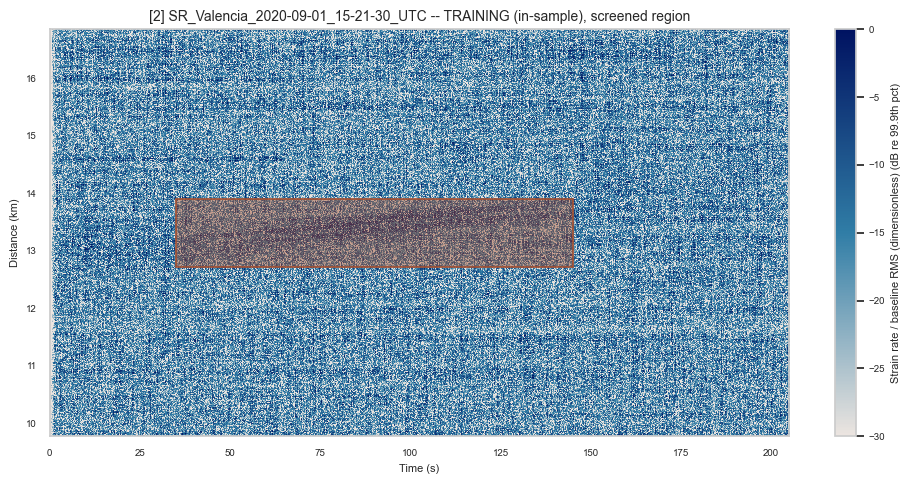

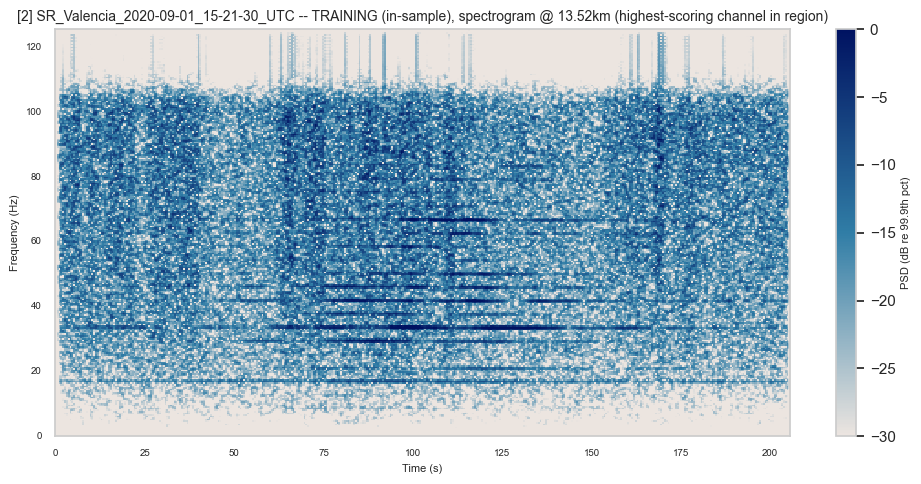

In [96]:
# --- 7b. Render selected candidate ---
# Re-run just this cell to inspect a different candidate -- change
# SELECTED_EVENT_IDX (1-based, matches the [N] index printed by 7a above)
# and re-run; no need to re-scan all events again (7a doesn't need to
# re-run unless DENSITY_WINDOW_M/MIN_DENSITY/MERGE_MAX_GAP_SEC change).
# View padding around the rendered candidate's own (already merged) region
# -- not a re-detection window, just how much extra context to show around
# the exact screened bounds. Plotting-only, so lives here with _render_event,
# not with 7a's screening parameters.
EVENT_ZOOM_TIME_PAD_SEC = 60.0
EVENT_ZOOM_DISTANCE_PAD_KM = 3.0
SELECTED_EVENT_IDX = 2

def _render_event(event_info):
    """Load one event's file, zoom to its screened region +/- padding, plot 3 views.

    Unlike the region-detection step above, this does NOT re-scan for
    clusters -- event_info already carries the exact screened bounds (from
    the candidate_events list below), so the rectangle in Plot 2 is drawn
    directly at those bounds; only the background waterfall's viewport is
    padded (EVENT_ZOOM_TIME_PAD_SEC / EVENT_ZOOM_DISTANCE_PAD_KM).

    Args:
        event_info: One entry of candidate_events -- a dict with idx,
            event_id, tag ("held-out" or "TRAINING (in-sample)"),
            t_start/t_end (region's own time span, s, unpadded),
            d_start/d_end (region's own distance span, km, unpadded), and
            peak_channel_global (the single highest-scoring channel inside
            the region, global channel index).
    """
    idx = event_info["idx"]
    event_id = event_info["event_id"]
    tag = event_info["tag"]
    _region_t_start, _region_t_end = event_info["t_start"], event_info["t_end"]
    _region_d_start, _region_d_end = event_info["d_start"], event_info["d_end"]
    _label = f"event{idx}"

    if tag != "held-out":
        print("NOTE: this is a TRAINING event -- final_pipeline saw these exact "
              "windows during .fit(), so a high score here is weaker evidence "
              "than a held-out candidate would be (CLAUDE.md SS9).")

    # Zoom bounds: the region's own span +/- a fixed pad, clamped to the
    # event's real extent (0 to FILES_PER_HOUR*600 s).
    _event_duration_s = FILES_PER_HOUR * 600
    _t_zoom_start = max(0.0, _region_t_start - EVENT_ZOOM_TIME_PAD_SEC)
    _t_zoom_end = min(_event_duration_s, _region_t_end + EVENT_ZOOM_TIME_PAD_SEC)
    _d_zoom_start = max(0.0, _region_d_start - EVENT_ZOOM_DISTANCE_PAD_KM)
    _d_zoom_end = _region_d_end + EVENT_ZOOM_DISTANCE_PAD_KM  # clamped below, once the file's real max distance is known

    # Single file covering the region's centre -- same simplification as
    # before (CLAUDE.md SS9): if the padded time window straddles a
    # 10-minute file boundary, it's clamped to the containing file's own
    # bounds rather than stitching two files together.
    _region_center_s = (_region_t_start + _region_t_end) / 2
    _file_idx = min(int(_region_center_s // 600), FILES_PER_HOUR - 1)
    _file = list_event_files(data_dir, event_id)[_file_idx]
    _local_t_zoom_start = max(0.0, _t_zoom_start - _file_idx * 600)
    _local_t_zoom_end = min(600.0, _t_zoom_end - _file_idx * 600)

    # FULL deep-water channel range, contiguous -- same recipe as 2b/2g/2k/2l,
    # not 3a-ii's strided one (this is a display background, not a rescoring).
    _file_event = load_h5_file(_file, channels=slice(DEEP_WATER_FIRST_CHANNEL, None))
    _distance_km_full = np.arange(_file_event.n_channels) * CHANNEL_SPACING_M / 1000
    _normalized_full, _ = preprocess_channels(
        _file_event.strain_rate, _file_event.fs, EDA_BANDPASS,
        _distance_km_full, baseline_rms_curve, channel_spacing=CHANNEL_SPACING_M,
        bad_channel_action="interpolate", fk_c_low=FK_C_LOW,
    )

    _t_start_sample = int(_local_t_zoom_start * _file_event.fs)
    _t_end_sample = int(_local_t_zoom_end * _file_event.fs)
    _d_zoom_end = min(_d_zoom_end, _distance_km_full[-1])
    _col_start = np.searchsorted(_distance_km_full, _d_zoom_start, side='left')
    _col_end = np.searchsorted(_distance_km_full, _d_zoom_end, side='right')

    _normalized_zoom = _normalized_full[_t_start_sample:_t_end_sample, _col_start:_col_end]
    _distance_km_zoom = _distance_km_full[_col_start:_col_end]
    _time_s_zoom = np.arange(_normalized_zoom.shape[0]) / _file_event.fs + _local_t_zoom_start

    _title_prefix = f'[{idx}] {event_id} -- {tag}'

    # --- Plot 1 (was: plain, no annotation) removed -- the marked version
    # (below) already shows the full waterfall, just with the screened
    # region additionally outlined, so the unmarked version was redundant.
    # --- Plot 1 (was Plot 2): the exact screened region, marked -- not a
    # re-detection, not a continuous score wash (CLAUDE.md SS9's "only keep
    # the screened red" rewrite): the rectangle is drawn directly at
    # event_info's own bounds, nothing else in the padded viewport is tinted. ---
    fig, ax = plot_waterfall(
        _normalized_zoom, _time_s_zoom, _distance_km_zoom,
        title=f'{_title_prefix}, screened region',
    )
    # BUG FIX (found by eye -- rectangle wasn't rendering for candidates
    # outside file 0): _region_t_start/_end are EVENT-relative (0-3600s),
    # but _time_s_zoom's axis is FILE-relative (0-600s, see
    # _local_t_zoom_start above) -- must subtract _file_idx*600 to land in
    # the same coordinate system, or the rectangle gets drawn far outside
    # the visible x-range (silently, since xlim is set explicitly below and
    # matplotlib doesn't autoscale to an out-of-range patch).
    _scored_channel_height_km = CHANNEL_STRIDE * CHANNEL_SPACING_M / 1000
    _rect_x = _region_t_start - _file_idx * 600
    _rect_w = _region_t_end - _region_t_start
    _rect_y = _region_d_start - _scored_channel_height_km / 2
    _rect_h = (_region_d_end - _region_d_start) + _scored_channel_height_km
    ax.add_patch(Rectangle((_rect_x, _rect_y), _rect_w, _rect_h,
                            facecolor=(*RED_2[:3], 0.45), edgecolor=RED_2, linewidth=1.2))
    ax.set_xlim(_time_s_zoom.min(), _time_s_zoom.max())
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'anomaly_spatial_waterfall_{_label}_annotated.png', dpi=150)
    plt.show()

    # --- Plot 2 (was Plot 3): spectrogram of the region's single highest-scoring channel
    # (event_info["peak_channel_global"], picked when candidate_events was
    # built, not re-derived here) --- a genuine time-frequency plot (STFT),
    # unlike 2e/2j's single-window Welch PSD, since we want to see how THIS
    # channel's frequency content evolves across the zoomed view.
    _peak_channel_global = event_info["peak_channel_global"]
    _peak_distance_km = _distance_km_full[_peak_channel_global - DEEP_WATER_FIRST_CHANNEL]
    _channel_signal = _normalized_full[_t_start_sample:_t_end_sample,
                                        _peak_channel_global - DEEP_WATER_FIRST_CHANNEL]

    _SPECTROGRAM_NPERSEG = 512  # ~2s segments at fs=250Hz -- balances time/frequency resolution
    _f_spec, _t_spec, _Zxx = stft(_channel_signal, fs=_file_event.fs, nperseg=_SPECTROGRAM_NPERSEG,
                                    noverlap=_SPECTROGRAM_NPERSEG * 3 // 4)
    _power_spec = np.abs(_Zxx) ** 2
    _ref_spec = np.percentile(_power_spec, 99.9)
    _db_spec = 10 * np.log10(np.maximum(_power_spec, _ref_spec * 1e-6) / _ref_spec)

    fig, ax = plt.subplots(figsize=FigSize.WIDE)
    im = ax.pcolormesh(_t_spec + _time_s_zoom.min(), _f_spec, _db_spec,
                        cmap=CMAP_BLUE, vmin=-30, vmax=0, shading='auto')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('PSD (dB re 99.9th pct)', fontsize=8)
    ax.set_xlabel('Time (s)', fontsize=8)
    ax.set_ylabel('Frequency (Hz)', fontsize=8)
    ax.set_title(f'{_title_prefix}, spectrogram @ {_peak_distance_km:.2f}km '
                 f'(highest-scoring channel in region)', fontsize=10)
    ax.tick_params(labelsize=7)
    ax.grid(False)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'anomaly_spatial_waterfall_{_label}_spectrogram.png', dpi=150)
    plt.show()




if not candidate_events:
    print("\nNothing to render -- no qualifying regions found.")
elif not (1 <= SELECTED_EVENT_IDX <= len(candidate_events)):
    print(f"\nSELECTED_EVENT_IDX={SELECTED_EVENT_IDX} out of range "
          f"(1..{len(candidate_events)}) -- nothing rendered.")
else:
    _selected = candidate_events[SELECTED_EVENT_IDX - 1]
    print(f"\nRendering candidate [{_selected['idx']}]: {_selected['event_id']} "
          f"@ t={_selected['t_start']:.0f}-{_selected['t_end']:.0f}s, "
          f"d={_selected['d_start']:.2f}-{_selected['d_end']:.2f}km  "
          f"[{_selected['tag']}]")
    _render_event(_selected)


## 8. Explainability

SHAP `TreeExplainer` on Isolation Forest's continuous **anomaly score**, not
a class probability -- there are no classes here (CLAUDE.md SS1/SS8.1).
`TreeExplainer` works directly with `IsolationForest` (tree-based) without
approximation. No `KernelExplainer` branch any more now that One-Class SVM
is gone (CLAUDE.md SS4/SS9) -- Isolation Forest is the only registered
model, so there's nothing to fall back to or choose between.

`shap_vals` has shape `(n_shap, n_features)` -- one row per sampled window,
one column per DSP feature, no class axis (unlike the predecessor bearing
project's multi-class `(n_samples, n_features, n_classes)`).

Computed on `X_test_final` (held-out `test_event_final` windows) only --
never on training windows, no leakage (same rule as before, restated for
the new unit of held-out data).

**Sign convention**: SHAP explains the underlying `IsolationForest`'s own
native `decision_function()` (sklearn convention: higher = more normal),
not `AnomalyDetectionPipeline.score()`'s flipped convention (higher = more
anomalous) used everywhere else in this notebook. `shap_vals` below is
negated once so "positive SHAP = pushes this window's `anomaly_scores`
higher" reads consistently with every other anomaly-score mention in this
notebook -- don't remove that negation when editing this cell.


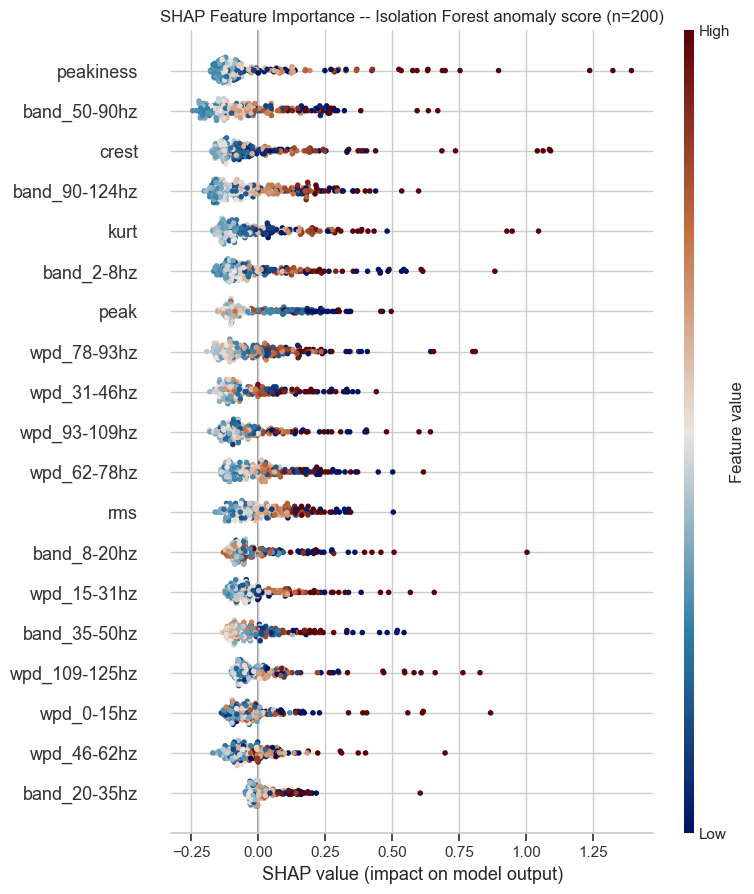


Top 10 features by mean |SHAP| (Isolation Forest, n=200):


,mean_abs_shap
peakiness,0.1643
band_50-90hz,0.1388
crest,0.1337
band_90-124hz,0.1330
kurt,0.1268
band_2-8hz,0.1219
peak,0.1187
wpd_78-93hz,0.1151
wpd_31-46hz,0.1040
wpd_93-109hz,0.1032


In [97]:
# =========================================================
# 8. Explainability
# =========================================================
# --- 8a. SHAP summary plot (beeswarm) ---
# Isolation Forest is the only registered model (CLAUDE.md SS4/SS9) -- no
# multi-model compatibility check needed, TreeExplainer works with it directly.
fitted_model = final_pipeline.fitted_pipelines['IsolationForest'].named_steps['model']
fitted_scaler = final_pipeline.fitted_pipelines['IsolationForest'].named_steps['scaler']

# Held-out test event only, subsampled to SHAP_SAMPLE_SIZE (Section 0b) --
# TreeExplainer is exact but still scales with n_samples x n_trees, and
# X_test_final can be ~10^5 rows (CLAUDE.md SS9).
rng = np.random.default_rng(RANDOM_STATE)
n_shap = min(SHAP_SAMPLE_SIZE, len(X_test_final))
_shap_idx = rng.choice(len(X_test_final), size=n_shap, replace=False)
X_shap = X_test_final[_shap_idx]
X_shap_scaled = fitted_scaler.transform(X_shap)

explainer = shap.TreeExplainer(fitted_model)
# Negate: TreeExplainer explains decision_function()'s native sklearn sign
# (higher = more normal) -- flipped here so positive SHAP consistently means
# "pushes this window's anomaly_scores higher", matching every other
# anomaly-score mention in this notebook (see md-sec8's sign-convention note).
shap_vals = -explainer.shap_values(X_shap_scaled)

# cmap=CMAP_DIVERGING (not shap's own built-in colormap) -- CLAUDE.md SS5:
# every plot's color comes from plot_style.py. Feature-value low-to-high is
# the same two-ended-scale role CMAP_DIVERGING already plays elsewhere.
plt.figure(figsize=FigSize.MULTI_PANEL)
shap.summary_plot(shap_vals, X_shap_scaled, feature_names=feature_names, cmap=CMAP_DIVERGING, show=False)
plt.title(f"SHAP Feature Importance -- Isolation Forest anomaly score (n={n_shap})")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 8b. Top features by mean |SHAP| ---
shap_summary = pd.Series(np.abs(shap_vals).mean(axis=0), index=feature_names, name="mean_abs_shap")
shap_summary = shap_summary.sort_values(ascending=False)

print(f"\nTop 10 features by mean |SHAP| (Isolation Forest, n={n_shap}):")
display(shap_summary.head(10).to_frame().style.format("{:.4f}"))


## 9. Summary & Conclusions

**Task:** fully unsupervised anomaly detection for submarine power-cable
health monitoring using Distributed Acoustic Sensing (DAS) -- Valencia-
IslaLink PubDAS dataset (Valencia-to-Mallorca telecom fiber, Sept 2020,
Febus A1-R interrogator, 250 Hz, 16.8 m channel spacing, first 50 km).
**There is no ground truth anywhere in this dataset** (CLAUDE.md SS1/SS9) --
every evaluation signal below is a proxy method, never precision, recall,
F1, or accuracy (CLAUDE.md SS15 #9).

**Full pipeline:**

| Step | Details |
|---|---|
| Data acquisition | Hourly event folders (`SR_Valencia_*_UTC`) via Globus, `MAX_HOURS`-capped |
| Preprocessing | Bad-channel interpolation -> common-mode removal -> detrend + bandpass -> f-k apparent-velocity highpass -> distance-baseline normalization (`preprocess_channels`) |
| DSP feature extraction | Sliding-window (`WINDOW_SEC`/`HOP_SEC`) time-domain (RMS, peak, crest, kurtosis) + non-uniform Welch PSD band energy + optional WPD sub-band energy |
| Distance decorrelation | Per-feature mean AND scale curves fit on training-fold events only, applied to train and test (`fit_distance_curves`/`apply_distance_curves`) |
| Split | Chronological, fixed, no cross-validation section -- the 3 earliest downloaded event-hours are the training set, the most recent (4th) hour is the held-out test set (Section 5) |
| Model | Isolation Forest only -- One-Class SVM tried and dropped (weak rank correlation with both IF and the baseline detector, Section 4) |
| Evaluation (no ground truth) | Spearman rank correlation vs. an independent hand-crafted z-score/L2-norm baseline detector (Section 5c) |
| Anomaly candidate screening | Spatially-coherent cluster detection over Isolation Forest's score (Section 7) -- requires several adjacent scored channels to exceed an empirical threshold within the same time window, not a single isolated high-scoring cell |
| Explainability | SHAP `TreeExplainer` on Isolation Forest's continuous anomaly score (Section 8) |
| Experiment tracking | MLflow -- parameters, metrics, fitted pipeline registered (Section 6b) |
| Deployment | Removed for this revision, not implemented -- see Appendix for why and what a future revision would build on |

---

**Key feature drivers:** see Section 8's SHAP summary plot/table (above) for
this run's ranked features -- not restated here as fixed numbers, since SHAP
importances are a property of the specific fitted model/run, not something
to hardcode into a narrative section that could drift from the actual output.

**On the anomaly-candidate screening step (Section 7):** a single
highest-scoring window/channel cell in a held-out event is weak evidence on
its own -- an isolated spike is more consistent with sensor or preprocessing
noise than a real physical event. Requiring several *adjacent* scored
channels to simultaneously exceed an empirical score threshold is a cheap,
label-free way to bias toward spatially-coherent, physically-plausible
candidates (e.g. a vessel transit affecting a contiguous stretch of cable)
over one-off statistical outliers -- see Section 7 for the exact criterion
(`MIN_ADJACENT_CHANNELS`) and its caveats (a training-event candidate is
weaker evidence than a genuinely held-out one, CLAUDE.md SS9).

---

**Limitations:**

1. **No ground truth anywhere in this dataset.** Every quality signal in
   this notebook (rank correlation with the baseline detector, spatially-
   coherent clustering) is a proxy, not a validated detection rate -- see
   CLAUDE.md SS9's full discussion of why binarized metrics
   (precision/recall/flag rate) are deliberately absent.
2. **Only a handful of events are downloaded** (`MAX_HOURS`) out of the full
   Sept 1-7 recording -- the chronological train/test split is real but
   statistically thin; a single held-out "future" hour says little about
   generalization across days, weather, or shipping-traffic patterns.
3. **No documented ground-truth events to validate most hours against** --
   only the anomaly-candidate screening step's spatial-coherence heuristic,
   and any independently published event metadata where it exists, offer
   qualitative support. A real deployment would need either instrumented
   validation events or a much longer observation period before trusting
   flagged candidates operationally.


## Appendix: API Deployment & Usage

**Removed for this revision, not implemented.** The predecessor bearing-fault
project served its model via FastAPI + Docker (`/predict_mat`, uploading a
`.mat` file). That code (`utils/inference_api.py`, `deployment/`,
`.github/workflows/ci.yml`) was never migrated for DAS -- it still expected
Paderborn `.mat` uploads and bearing fault classes, which don't apply here --
and has now been deleted rather than left half-adapted (CLAUDE.md's own rule:
describe the project as it actually exists, not an aspirational half-state).

**Why not just adapt it**: the request contract genuinely isn't decided yet.
A DAS inference request would need to accept either a raw strain-rate window
(one or more channels, some duration) or a pre-extracted feature vector, then
run the same preprocessing -> feature-extraction -> `IsolationForest.score()`
path this notebook already exercises -- but unlike the bearing project's
single `.mat` file boundary, there's a real design question here (how many
channels per request? pre-extracted features, or raw samples the server
extracts features from? one window or a batch?) that doesn't have an obvious
default, and guessing one just to have *something* here would misrepresent
the actual state of the project.

**If this returns in a future revision**, the pieces already available to
build on: `AnomalyDetectionPipeline`/`final_pipeline` (`utils/anomaly_models.py`,
trained and evaluated in Sections 4-5), `preprocess_channels()` +
`extract_window_features()` (`utils/data_preprocess.py` /
`utils/dsp_features.py`, the same functions this notebook's own pipeline
calls, so serving would reuse them rather than reimplementing), and the
MLflow model registry (`mlruns/`, `das_anomaly_isolationforest`) this
notebook's Section 6b logs to.
